# Age prediction from single-cell PBMC data with `patpy`

This tutorial benchmarks six sample-representation methods on the task of
**predicting biological age from PBMC scRNA-seq profiles**, then validates
the biological conclusions on an independent cohort, and finally cracks
open one of the supervised models (SampleCLR) to read the per-cell
attention weights that drive its age prediction.

The methods cover the four flavours of sample-level analysis exposed by
`patpy`:

- **Pseudobulk** (`patpy.tl.Pseudobulk`) — mean of cell embeddings per donor.
- **Cell-group composition with CLR** (`patpy.tl.CellGroupComposition`) — the
  fractions of every cell type in a donor, centred-log-ratio transformed.
- **GloScope** (`patpy.tl.GloScope_py`) — KL-divergence between donor-level
  cell-state distributions.
- **SampleCLR** ([package](https://github.com/lueckenlab/SampleCLR)) — a
  contrastive sample-level model with a self-supervised + supervised stage.
- **PaSCient** (`patpy.tl.PaSCient`) — cell→patient attention model.
- **MixMIL** (`patpy.tl.MixMIL`) — mixed-model multiple-instance learning.

We run them on the **AIFI Immunobiology of Aging** cohort (234 donors,
ages 40–89, 3.76 M PBMCs across 17 sequencing batches) and validate on
**OneK1K** (981 donors, ages 19–97).

Two questions:

1. **Engineering:** which sample representation best preserves age signal
   while not encoding the sequencing batch?
2. **Biology:** what changes in immune composition / per-cell-type
   transcription are reproducible across cohorts, and what genes drive
   the age signal inside the cell types the model pays the most
   attention to?

The notebook is self-contained — every fit, score and figure comes
from running its own cells. On a single CPU core a full pass takes
30–60 minutes; PaSCient finishes much faster on a GPU.

## Setup

Set ``SMOKE = True`` to iterate on a ~20-donor subset (good for debugging).
Every method — the baselines and the slow MIL methods alike — sees **all** of each
donor's cells; we never pre-subsample. A single **age-stratified train/validation
split** is reused by all methods: unsupervised methods train their probe on the
train donors, supervised methods train the model itself on the train donors, and
every score is reported on the **held-out validation donors**.

In [1]:
# !pip install -U git+https://github.com/lueckenlab/patpy.git@feature/sampleclr-integration


In [2]:
%load_ext autoreload
%autoreload 2
import copy
import gc, os, time, warnings
from pathlib import Path

# Silence per-epoch training progress bars / framework logs so the methods below
# don't flood the notebook (SampleCLR already runs with verbose=False).
os.environ["TQDM_DISABLE"] = "1"

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

import patpy

warnings.filterwarnings("ignore", category=UserWarning)

import logging
for _logger in ("lightning.pytorch", "pytorch_lightning", "lightning"):
    logging.getLogger(_logger).setLevel(logging.ERROR)

# Plotting defaults: no grid, despine top + right, frameless UMAPs.
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sc.set_figure_params(dpi=80, frameon=False)

def despine(*axes):
    """Drop the top/right spines on every axis passed in."""
    for ax in axes:
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        ax.grid(False)

def style_umap(ax):
    """Strip frame + ticks from an embedding scatter."""
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

SEED = 42

SMOKE = False
DATA_ROOT = Path("/ictstr01/groups/luckylab/workspace/vladimir.shitov/"
                 "patpy-aging-tutorial/data/aging_benchmark")
SMOKE_SUFFIX = "_smoke" if SMOKE else ""
ARTIFACT_DIR = DATA_ROOT / f"notebook_artifacts{SMOKE_SUFFIX}"
FIG_DIR = ARTIFACT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show(name, fig=None):
    """Save the current figure to FIG_DIR/<name>.pdf, then display it inline."""
    (fig or plt.gcf()).savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()

print("patpy", patpy.__version__, " · torch.cuda.is_available()", torch.cuda.is_available())


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


patpy 0.17.0  · torch.cuda.is_available() True


In [3]:
TRAIN_BAG_SIZE = 256 if SMOKE else 1000

# Held-out (validation) fraction for the age-stratified donor split.
VAL_FRACTION = 0.20
N_NEIGHBORS = 5

# Recompute the slow models (GloScope / PaSCient / MixMIL) even if a cached result
# exists on disk. Leave False to reuse precomputed results for fast iteration.
FORCE_RECOMPUTE = False

SCLR_BATCH_SIZE = 8
SCLR_LAMBDA = 7.324       # t61 (FT-CV study trial 61)
SCLR_SSL_TEMP = 0.5       # raised from t61's 0.132; the sharp (low) SSL temp made FT collapse attention to 0
SCLR_FT_TEMP = 0.099      # t61
SCLR_FT_LR_FACTOR = 0.1   # fine-tune at base_lr * factor (3e-4 -> 3e-5); the default 3e-4 FT lr collapsed attention
SCLR_CELLS_INTERVAL = 512
SCLR_VAL_INNER = 0.20
SCLR_ATTN_SPARSITY = 1e-4   # disable attention sparsity penalty (was lib default 1e-4)
SCLR_SSL_EPOCHS = 10 if SMOKE else 40   # SSL/stage-1 pretrain epochs (raised from 40/30)

SCLR_ARCH = dict(
    num_layers=2,
    hidden_size=256,
    n_aggregator_heads=2,
    aggregator_num_layers=3, 
    aggregator_hidden_size=256, 
    output_dim=64
)

## The AIFI Immunobiology of Aging cohort

The AIFI **Immunobiology of Aging** dataset is 234 healthy donors aged
40–89, with PBMCs profiled at single-cell resolution under one
protocol but split across 17 well-balanced sequencing batches.

We load the precomputed h5ad (HVG + log-normalised + 50 PCs in
``.obsm["X_pca"]``) and clean the age column (the AIFI release encodes
ages ≥89 as the literal string ``"89+"``).

In [4]:
AIFI_PATH = "/ictstr01/groups/luckylab/workspace/vladimir.shitov/aifi_data/imm_of_aging/imm-of-aging_pp.h5ad"


def add_clean_obs(adata):
    adata.obs["age"] = pd.to_numeric(adata.obs["sample.subjectAgeAtDraw"].astype(str).str.replace("+", ""))
    adata.obs["age_group"] = np.where(adata.obs["age"] >= 65, "old", "young")
    adata.obs["donor"] = adata.obs["subject.subjectGuid"].astype(str)
    return adata


def load_aging(smoke=False, n_donors=20, seed=42):
    """Read the AIFI aging cohort.

    In smoke mode, slice donors before materialising so we never pull the full
    5 GB into memory on a small machine.
    """
    if smoke:
        aging = ad.read_h5ad(AIFI_PATH, backed="r")
        donors = pd.unique(aging.obs["subject.subjectGuid"].astype(str))
        rng = np.random.default_rng(seed)
        donors = donors[rng.permutation(len(donors))[:n_donors]]
        keep_cells = aging.obs["subject.subjectGuid"].astype(str).isin(set(donors.tolist())).values
        aging = aging[keep_cells].to_memory()
    else:
        aging = ad.read_h5ad(AIFI_PATH)
    return add_clean_obs(aging)


t0 = time.time()
adata = load_aging(smoke=SMOKE)
print(f"loaded in {time.time() - t0:.1f}s - n_cells={adata.n_obs:,} n_genes={adata.n_vars}")
print(f"n_donors={adata.obs['donor'].nunique()}  age range={adata.obs['age'].min():.0f}-{adata.obs['age'].max():.0f}")


loaded in 66.2s - n_cells=3,758,514 n_genes=4000
n_donors=234  age range=40-89


        age age_group     sex       cmv              race    batch     pool  \
donor                                                                         
SF3001   52     young  Female  Negative  African American  B172-PC  B172-PC   
SF3006   68       old    Male  Positive   American Indian  B172-PC  B172-PC   
SF3016   47     young    Male  Negative         Caucasian  B171-PB  B171-PB   
SF3020   70       old  Female  Positive             Asian  B155-PA  B155-PA   
SF3024   50     young  Female  Positive   American Indian  B172-PB  B172-PB   

             chip  n_cells  
donor                       
SF3001  B172-PCC1    24303  
SF3006  B172-PCC1    12390  
SF3016  B171-PBC1    17827  
SF3020  B155-PAC1    18050  
SF3024  B172-PBC1    24252  


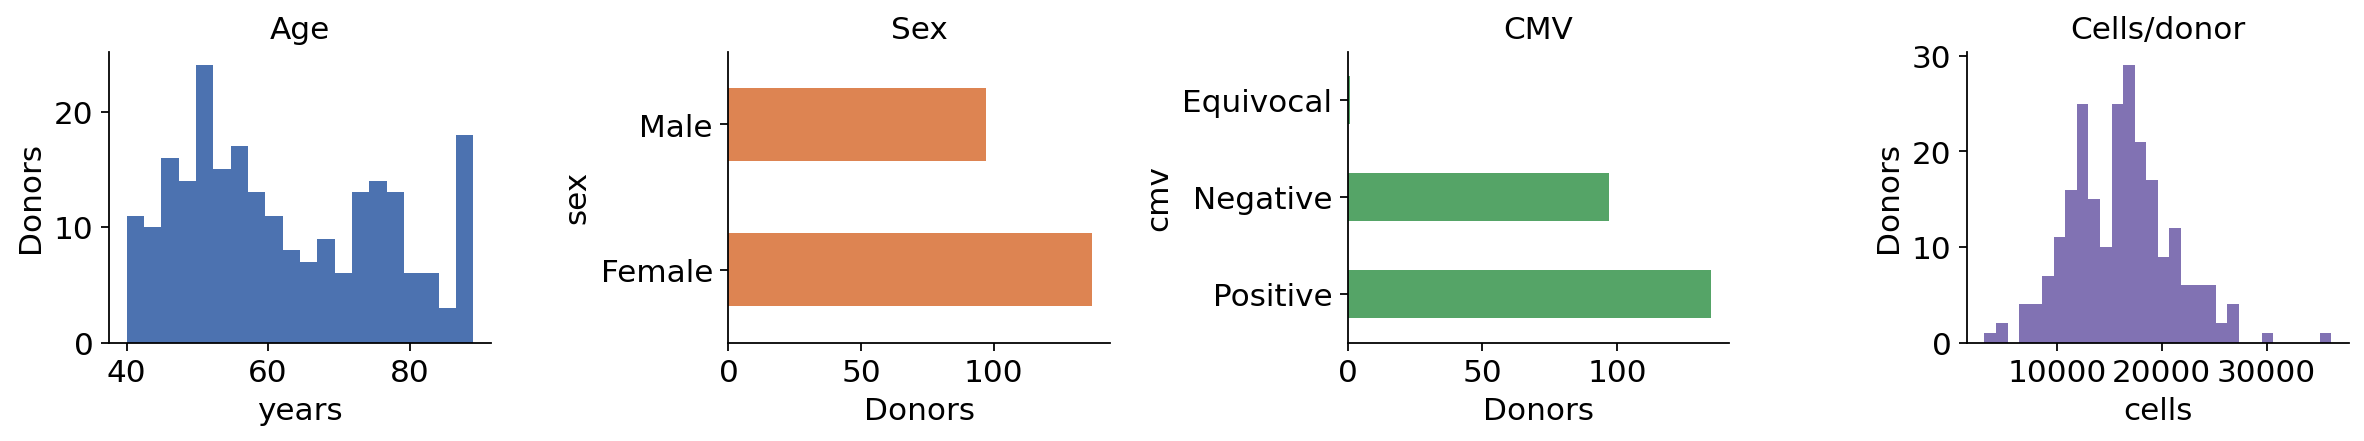

In [5]:
# Build a donor-level metadata table; we re-use it for every method below.
def donor_meta_from(adata, age_col="age", sample_col="donor",
                    keep=("subject.biologicalSex", "subject.cmv", "subject.race", "batch_id", "pool_id", "chip_id", "AIFI_L2")):
    cols = [sample_col, age_col, "age_group"] + [c for c in keep if c in adata.obs.columns]
    return adata.obs[cols].copy().groupby(sample_col, observed=True).agg(
        age=("age", "first"),
        age_group=("age_group", "first"),
        sex=("subject.biologicalSex", "first"),
        cmv=("subject.cmv", "first"),
        race=("subject.race", "first"),
        batch=("batch_id", "first"),
        pool=("pool_id", "first"),
        chip=("chip_id", "first"),
        n_cells=("AIFI_L2", "size"),
    )

donor_meta = donor_meta_from(adata)
print(donor_meta.head())

# Cohort overview: age + cells/donor as histograms, sex + CMV as horizontal bars
# (horizontal bars keep the category labels readable).
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes[0].hist(donor_meta.age, bins=20, color="#4C72B0")
axes[0].set_title("Age"); axes[0].set_xlabel("years"); axes[0].set_ylabel("Donors")
donor_meta.sex.value_counts().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Sex"); axes[1].set_xlabel("Donors")
donor_meta.cmv.value_counts().plot(kind="barh", ax=axes[2], color="#55A467")
axes[2].set_title("CMV"); axes[2].set_xlabel("Donors")
axes[3].hist(donor_meta.n_cells, bins=30, color="#8172B3")
axes[3].set_title("Cells/donor"); axes[3].set_xlabel("cells"); axes[3].set_ylabel("Donors")
despine(*axes)
plt.tight_layout(); save_and_show("cohort_overview")


In [6]:
adata.obs.columns

Index(['cohort.cohortGuid', 'subject.subjectGuid', 'sample.sampleKitGuid',
       'specimen.specimenGuid', 'subject.biologicalSex',
       'subject.ageAtFirstDraw', 'subject.race', 'subject.ethnicity',
       'subject.cmv', 'sample.visitName', 'sample.subjectAgeAtDraw',
       'batch_id', 'pool_id', 'chip_id', 'well_id', 'barcodes',
       'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes',
       'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1',
       'predicted_AIFI_L1', 'AIFI_L2', 'predicted_AIFI_L2', 'AIFI_L3',
       'predicted_AIFI_L3', 'cell_population_file', 'age', 'age_group',
       'donor'],
      dtype='object')

### Pre-existing biology: composition shifts with age

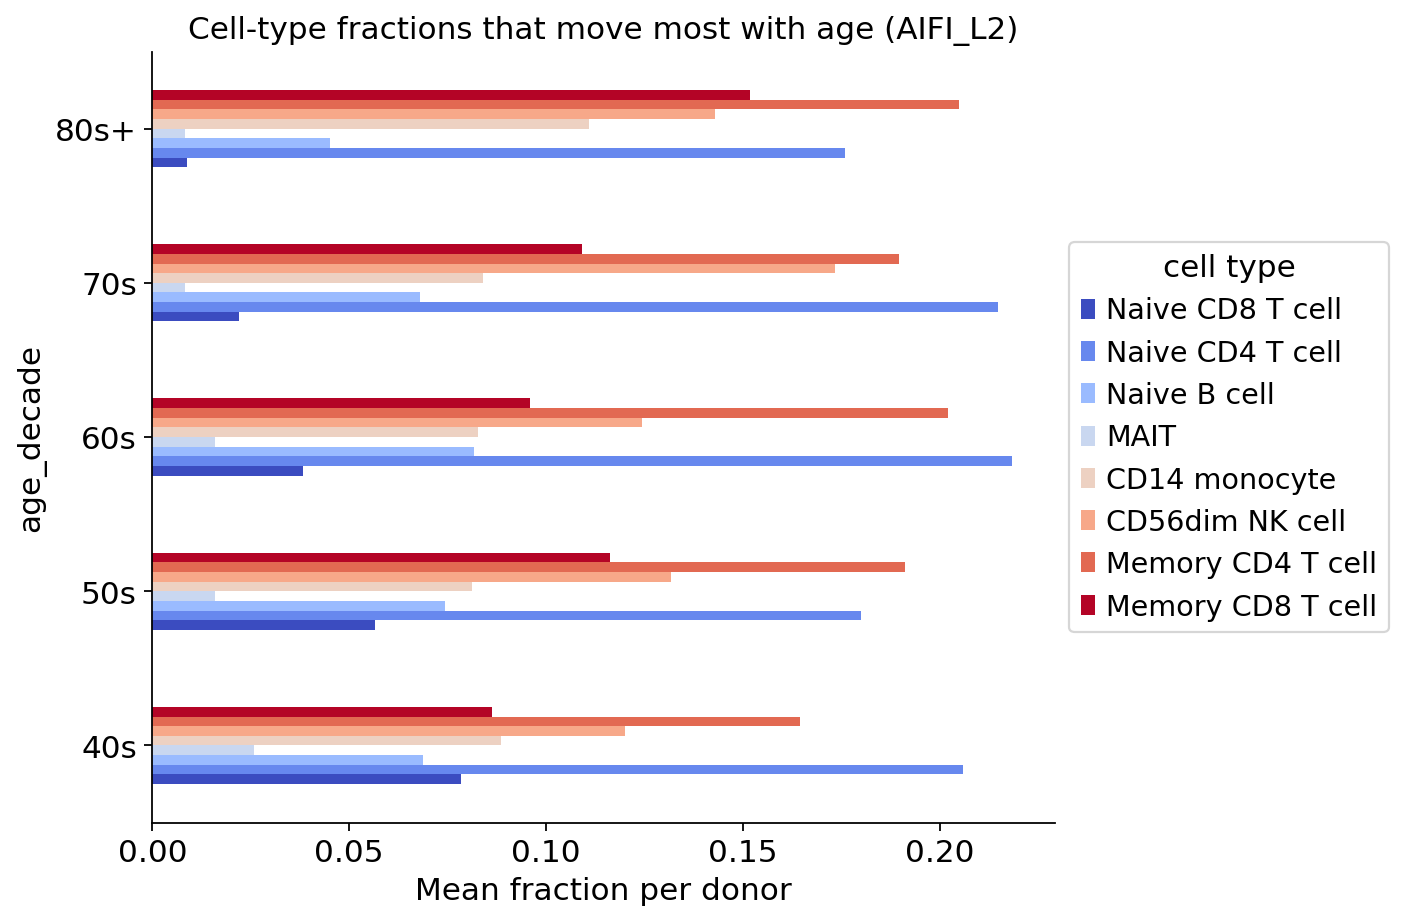

In [7]:
# Per-donor AIFI_L2 fractions, then mean by age decade.
celltype_fractions = pd.crosstab(
    adata.obs["donor"].astype(str), adata.obs["AIFI_L2"].astype(str), normalize="index"
)
donor_meta["age_decade"] = pd.cut(
    donor_meta.age, bins=[39, 50, 60, 70, 80, 90],
    labels=["40s", "50s", "60s", "70s", "80s+"], right=False,
)
fraction_by_decade = (
    celltype_fractions.join(donor_meta["age_decade"])
    .groupby("age_decade", observed=True)
    .mean()
)
fraction_change = (fraction_by_decade.iloc[-1] - fraction_by_decade.iloc[0]).sort_values()
top_movers = list(fraction_change.head(4).index) + list(fraction_change.tail(4).index)

ax = fraction_by_decade.loc[:, top_movers].plot(kind="barh", colormap="coolwarm", figsize=(9, 6))
ax.set_xlabel("Mean fraction per donor"); ax.set_xlim(0, None)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="cell type")
ax.set_title("Cell-type fractions that move most with age (AIFI_L2)")
despine(ax)
plt.tight_layout(); save_and_show("celltype_fractions_by_decade")


## Shared utilities

Most of the work is the same for every method: filter small donors, pick
a train/test donor split, fit the method, compute a held-out K-NN
regression of age, score the technical / biological covariates. We
define the helpers once.

In [8]:
def smoke_subset(adata, n_donors=20, seed=SEED):
    """Restrict an AnnData to a small random set of donors (SMOKE only).

    No cell capping — within the kept donors every cell is used, exactly as in a
    full run.
    """
    rng = np.random.default_rng(seed)
    donors = pd.unique(adata.obs["donor"].astype(str))
    donors = donors[rng.permutation(len(donors))[:n_donors]]
    return adata[adata.obs["donor"].astype(str).isin(set(donors.tolist()))].copy()


if SMOKE:
    # adata was already restricted to ~20 donors at load (load_aging(smoke=True));
    # nothing more to cap — every method still sees all of each donor's cells.
    donor_meta = donor_meta_from(adata)
    print(f"smoke subset: n_cells={adata.n_obs:,}  n_donors={adata.obs['donor'].nunique()}")

In [9]:
def donor_train_val_split(donors, ages, val_fraction=VAL_FRACTION, seed=SEED, n_bins=5):
    """Age-stratified donor split.

    Ages are binned into quantiles and ``val_fraction`` of each bin is held out,
    so the train and validation sets both span the full age range. Returns
    ``(train_donors, val_donors)`` as lists of donor-id strings.
    """
    from sklearn.model_selection import train_test_split

    donors = np.asarray([str(d) for d in donors])
    age = pd.Series(ages)
    age.index = age.index.astype(str)
    age = age.reindex(donors).astype(float)
    # Keep bins small enough that each has >=2 donors (stratified split needs it).
    n_bins = max(2, min(n_bins, len(donors) // 10, age.nunique()))
    bins = pd.qcut(age, q=n_bins, duplicates="drop").cat.codes.values
    train, val = train_test_split(donors, test_size=val_fraction, random_state=seed, stratify=bins)
    return list(train), list(val)


def score_distance_knn_heldout(distances, target_per_sample, sample_order,
                               train_labels, val_labels, n_neighbors=N_NEIGHBORS):
    """Held-out KNN regression on a precomputed distance matrix.

    Each *validation* donor's age is predicted from its ``n_neighbors`` nearest
    *training* donors only — the distance-method analogue of a probe trained on
    the train set and evaluated on the held-out val set. Suitable for
    distance-only methods such as GloScope that have no sample embedding.
    """
    sample_order = [str(s) for s in sample_order]
    position = {s: i for i, s in enumerate(sample_order)}
    target = pd.Series(target_per_sample)
    target.index = target.index.astype(str)

    train_idx = [position[d] for d in map(str, train_labels)
                 if d in position and np.isfinite(target.get(d, np.nan))]
    distances = np.asarray(distances, dtype=float)
    y_true, y_pred = [], []
    for donor in map(str, val_labels):
        if donor not in position or not np.isfinite(target.get(donor, np.nan)):
            continue
        row = distances[position[donor], train_idx]
        nearest = np.argsort(row)[:n_neighbors]
        y_pred.append(np.mean([target[sample_order[train_idx[j]]] for j in nearest]))
        y_true.append(target[donor])
    return patpy.tl.evaluate_regression(np.asarray(y_true), np.asarray(y_pred))


def pascient_predict_on(pascient, adata):
    """Re-point a trained PaSCient at a new in-memory cohort and predict age.

    PaSCient.prepare_anndata(train=False) needs a checkpoint on disk, so for an
    already-trained model we swap the cohort and re-extract its cell embeddings.
    """
    pascient.adata = adata
    pascient.samples = pd.unique(adata.obs["donor"].astype(str)).tolist()
    pascient._cell_embeddings = {}
    pascient._extract_embeddings(adata)
    return pascient.predict("age")


def classical_mds(distances, n_components=16):
    """Classical (Torgerson) MDS embedding of a square distance matrix."""
    distances = np.asarray(distances, dtype=np.float64)
    n_samples = distances.shape[0]
    centering = np.eye(n_samples) - np.ones((n_samples, n_samples)) / n_samples
    gram = -0.5 * centering @ (distances**2) @ centering
    eigenvalues, eigenvectors = np.linalg.eigh(gram)
    top = np.argsort(-eigenvalues)[:n_components]
    return eigenvectors[:, top] * np.sqrt(np.clip(eigenvalues[top], 0, None))


# Colour palette for the metric comparison plots.
# Dark red = SampleCLR, salmon = PaSCient, green = MixMIL (deliberately not a blue
# tone), blue = unsupervised SampleCLR-SSL, gold = PULSAR foundation model.
METHOD_COLORS = {
    "unsupervised":   "#7FA8D6",  # pale blue (pseudobulk / composition / gloscope)
    "SampleCLR SSL":  "#0F52BA",  # saturated blue (self-supervised)
    "SampleCLR FT":   "#8B1A1A",  # dark red (fine-tuned)
    "PaSCient":       "#FA8072",  # salmon
    "MixMIL":         "#FA8072",  # salmon (match supervised PaSCient)
    "PULSAR":         "#E8A200",  # gold
    "PULSAR aligned": "#E8A200",  # gold (same as PULSAR)
}

METHOD_COLOR_BY_LABEL = {
    "pseudobulk":     METHOD_COLORS["unsupervised"],
    "composition":    METHOD_COLORS["unsupervised"],
    "gloscope":       METHOD_COLORS["unsupervised"],
    "sampleclr-SSL":  METHOD_COLORS["SampleCLR SSL"],
    "sampleclr-FT":   METHOD_COLORS["SampleCLR FT"],
    "pascient":       METHOD_COLORS["PaSCient"],
    "mixmil":         METHOD_COLORS["MixMIL"],
    "PULSAR":         METHOD_COLORS["PULSAR"],
    "PULSAR aligned": METHOD_COLORS["PULSAR aligned"],
    # FT-fraction sweep uses the short lowercase name:
    "sampleclr":      METHOD_COLORS["SampleCLR FT"],
}


def method_color(label):
    return METHOD_COLOR_BY_LABEL.get(label, "#888888")


# One age-stratified train / validation split, reused by EVERY method below:
# unsupervised methods train their probe on `train_donors`; supervised methods
# train the model itself on `train_donors`. All scores are reported on the
# held-out `val_donors`.
donor_order = list(pd.unique(adata.obs["donor"].astype(str)))
train_donors, val_donors = donor_train_val_split(donor_order, donor_meta["age"])
print(f"split (age-stratified): train={len(train_donors)} val={len(val_donors)}")

# --- Slow-model result cache (GloScope / PaSCient / MixMIL) -----------------
# Their headline embeddings, distances and held-out scores are pickled here and
# reloaded on later runs. Set FORCE_RECOMPUTE = True (above) to recompute.
import pickle

SLOW_CACHE_DIR = Path("/ictstr01/groups/luckylab/workspace/vladimir.shitov/"
                      "patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts/slow_model_cache")


def load_or_compute_slow(name, compute_fn):
    """Return cached slow-model outputs, or compute them and cache.

    ``compute_fn()`` must return a dict of picklable results (numpy / pandas /
    plain dicts — not torch models). ``FORCE_RECOMPUTE`` bypasses the cache, and
    the cache key includes the SMOKE flag so smoke and full runs never collide.
    Changed a model's hyperparameters? Set FORCE_RECOMPUTE = True (or delete the
    file) so a stale cache is not silently reused.
    """
    SLOW_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    path = SLOW_CACHE_DIR / f"{name}{'_smoke' if SMOKE else ''}.pkl"
    if not FORCE_RECOMPUTE and path.exists():
        with open(path, "rb") as handle:
            result = pickle.load(handle)
        print(f"[{name}] loaded cached results from {path.name} (set FORCE_RECOMPUTE=True to redo)")
        return result
    result = compute_fn()
    with open(path, "wb") as handle:
        pickle.dump(result, handle)
    print(f"[{name}] computed and cached -> {path.name}")
    return result


def resolve_cells_per_sample(adata, spec=SCLR_CELLS_INTERVAL):
    """Concrete n_cells_per_sample; an interval's upper bound is clamped to half
    the cohort's median cells/donor (the bag never exceeds half a typical donor)."""
    counts = adata.obs.groupby("donor", observed=True).size()
    cap = max(1, int(np.median(counts) // 2))
    if isinstance(spec, (tuple, list)):
        low, high = int(spec[0]), int(spec[1])
        high = min(high, cap)
        low = min(low, max(1, high - 1))
        return (low, high)
    return int(spec)


def set_sclr_ft_temperature(model, temp=SCLR_FT_TEMP):
    """Switch SampleCLR's contrastive temperature to the fine-tuning value in place."""
    model.contrastive_loss_temperature = temp
    if getattr(model, "criterion", None) is not None and hasattr(model.criterion, "temperature"):
        model.criterion.temperature = temp


def set_finetune_lr(model, factor=SCLR_FT_LR_FACTOR):
    """Lower SampleCLR's fine-tune base LR by ``factor`` in place.

    SampleCLR fine-tunes with the same Adam optimizer used for pretrain, and
    ``fine_tune`` rebuilds its warmup+cosine schedule from the optimizer's
    ``initial_lr``. The default 3e-4 fine-tune LR drives the relu attention to
    zero (the donor embedding collapses to a constant and age prediction fails),
    so we scale the base LR down before fine-tuning. The pretrain LR is untouched.
    """
    optimizer = getattr(model, "feature_optimizer", None) or getattr(model, "optimizer", None)
    for group in optimizer.param_groups:
        group["initial_lr"] = group.get("initial_lr", group["lr"]) * factor
        group["lr"] = group["lr"] * factor
    if hasattr(model, "learning_rate_feature"):
        model.learning_rate_feature *= factor

split (age-stratified): train=187 val=47


## Method 1 — Pseudobulk

Mean of the cell-level `X_pca` embedding within each donor, Euclidean
distance between those means. Cheap, interpretable, ignores
within-donor heterogeneity.

In [10]:
# Pseudobulk: mean of the per-cell X_pca embedding per donor. We score age with
# patpy's built-in linear probe (Ridge): trained on train_donors, evaluated on
# the held-out val_donors.
t0 = time.time()
pseudobulk = patpy.tl.Pseudobulk(
    sample_key="donor",
    cell_group_key="AIFI_L2",
    layer="X_pca",
    seed=SEED,
)
pseudobulk.prepare_anndata(adata)
dist_pb = pseudobulk.calculate_distance_matrix()
emb_pb = pd.DataFrame(pseudobulk.sample_representation, index=pseudobulk.samples)

score_pb = pseudobulk.fit_linear_probe("age", task="regression", test_sample_labels=val_donors)
print(f"pseudobulk: {time.time() - t0:.1f}s  Pearson r={score_pb['pearson']:.3f}  "
      f"Spearman={score_pb['spearman']:.3f}  MAE={score_pb['mae']:.2f}")

pseudobulk: 11.8s  Pearson r=0.643  Spearman=0.661  MAE=8.88


## Method 2 — Cell-group composition (CLR)

In [11]:
# Cell-group composition (CLR): the centred-log-ratio of per-donor cell-type
# fractions. Same held-out linear-probe scoring as pseudobulk.
t0 = time.time()
composition = patpy.tl.CellGroupComposition(
    sample_key="donor",
    cell_group_key="AIFI_L2",
    apply_clr=True,
    seed=SEED,
)
composition.prepare_anndata(adata)
dist_comp = composition.calculate_distance_matrix()
representation = composition.sample_representation
emb_comp = representation if isinstance(representation, pd.DataFrame) else pd.DataFrame(representation, index=composition.samples)

score_comp = composition.fit_linear_probe("age", task="regression", test_sample_labels=val_donors)
print(f"composition (CLR): {time.time() - t0:.1f}s  Pearson r={score_comp['pearson']:.3f}  "
      f"Spearman={score_comp['spearman']:.3f}  MAE={score_comp['mae']:.2f}")

composition (CLR): 0.9s  Pearson r=0.742  Spearman=0.764  MAE=7.16


## Method 3 — GloScope (Python)

In [12]:
# GloScope: symmetric KL divergence between donor-level cell-state distributions.
# It produces distances, not an embedding, so we score age by held-out KNN. The
# (slow, GPU) distance computation is cached — set FORCE_RECOMPUTE=True to redo.
def _compute_gloscope():
    gloscope = patpy.tl.GloScope_py(
        sample_key="donor",
        cell_group_key="AIFI_L2",
        layer="X_pca",
        k=25,
        seed=SEED,
        use_gpu=True,
    )
    gloscope.prepare_anndata(adata)
    distances = gloscope.calculate_distance_matrix()
    dist = (distances.values if isinstance(distances, pd.DataFrame) else np.asarray(distances)).astype(np.float32)
    samples = list(distances.index) if isinstance(distances, pd.DataFrame) else list(gloscope.samples)
    emb = pd.DataFrame(classical_mds(dist, n_components=15), index=samples)
    score = score_distance_knn_heldout(dist, donor_meta["age"], samples, train_donors, val_donors)
    return {"emb": emb, "dist": dist, "samples": samples, "score": score}


t0 = time.time()
_gs = load_or_compute_slow("gloscope", _compute_gloscope)
emb_gs, dist_gs, gloscope_samples, score_gs = _gs["emb"], _gs["dist"], _gs["samples"], _gs["score"]
print(f"GloScope_py: {time.time() - t0:.1f}s  Pearson r={score_gs['pearson']:.3f}  "
      f"Spearman={score_gs['spearman']:.3f}  MAE={score_gs['mae']:.2f}")

[gloscope] loaded cached results from gloscope.pkl (set FORCE_RECOMPUTE=True to redo)
GloScope_py: 0.0s  Pearson r=0.529  Spearman=0.465  MAE=9.83


SampleCLR trains a contrastive aggregator over cell embeddings. We snapshot the
donor embedding at the **SSL** stage (after self-supervised pretrain, no labels)
and after **fine-tuning** on age. The SSL stage has no supervised head, so we
score it with a linear probe; the fine-tuned model has a trained age head, so we
read its prediction directly (`predict`). We also pull per-cell attention weights
for the deeper analysis below.

The `use_batch_aware_sampler` flag tells the contrastive loss to balance
sequencing batches when forming positive/negative pairs — useful when the
technical batches are confounded with biology. We use a `relu` attention
activation; the saturating sigmoid default underweights informative cells.


In [13]:
def fit_sampleclr(adata, train_donors):
    """Train SampleCLR (via patpy.tl.SampleCLR) on the TRAIN donors only.

    Pretrains (SSL) then fine-tunes the age head on the train donors, snapshots
    the SSL aggregator for the attention analysis, and embeds *all* donors
    (train + held-out) with both the SSL and the fine-tuned model so held-out
    donors are encoded identically. Returns the patpy ``SampleCLR`` wrapper, the
    underlying ``ContrastiveModel`` and the SSL/FT donor embeddings + distances.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_adata = adata[adata.obs["donor"].astype(str).isin(set(map(str, train_donors)))].copy()
    all_donors = np.array(pd.unique(adata.obs["donor"].astype(str)))
    # Inner age-stratified split of the train donors -> SampleCLR early stopping.
    inner_train, inner_val = donor_train_val_split(
        train_donors, donor_meta["age"], val_fraction=SCLR_VAL_INNER, seed=SEED)
    n_epochs = 10 if SMOKE else 40
    arch = {key: value for key, value in SCLR_ARCH.items() if key != "output_dim"}  # output_dim is an explicit arg

    sampleclr = patpy.tl.SampleCLR(
        sample_key="donor",
        label_keys=["age"],
        tasks=["regression"],
        layer="X_pca",
        output_dim=SCLR_ARCH["output_dim"],
        n_cells_per_sample=resolve_cells_per_sample(train_adata),   # random bag, clamped to half-median
        num_epochs_pretrain=SCLR_SSL_EPOCHS,
        num_epochs_fine_tune=n_epochs,
        batch_size=SCLR_BATCH_SIZE,
        device=device,
        seed=SEED,
        # everything below is forwarded to the underlying ContrastiveModel:
        lambda_=SCLR_LAMBDA,
        contrastive_loss_temperature=SCLR_SSL_TEMP,     # SSL (unsupervised) temperature
        aggregator_activation="relu",
        attention_sparsity_lambda=SCLR_ATTN_SPARSITY,
        use_batch_aware_sampler=False,
        early_stopping_patience=3 if SMOKE else 25,
        verbose=True,
        train_ids=list(inner_train),
        val_ids=list(inner_val),
        **arch,
    )

    def embed_all_donors():
        """Embed the FULL cohort (train + held-out) through patpy's interface.

        ``get_sample_representations()`` runs the trained projector + aggregator
        over every donor's cells; ``calculate_distance_matrix()`` turns those
        embeddings into a donor-donor (cosine) distance matrix.
        """
        sampleclr.adata = adata
        sampleclr.samples = all_donors
        sampleclr.sample_representation = None   # force a fresh embedding over the full cohort
        embedding = sampleclr.get_sample_representations().copy()
        embedding.index = embedding.index.astype(str)
        distances = sampleclr.calculate_distance_matrix(dist="cosine").astype(np.float32)
        return embedding, distances

    # SSL snapshot: self-supervised pretrain on the train donors (no age head yet).
    sampleclr.prepare_anndata(
        train_adata, pretrain=True, fine_tune=False,
        pretrain_val_metric="loss",
        pretrain_num_warmup_epochs=max(1, SCLR_SSL_EPOCHS // 5),
        verbose=False,
    )
    ssl_aggregator = copy.deepcopy(sampleclr._sclr_model.aggregator).eval()  # reused by the attention analysis
    emb_ssl, dist_ssl = embed_all_donors()

    # FT snapshot: switch to the fine-tuning contrastive temperature, train the age head.
    set_sclr_ft_temperature(sampleclr._sclr_model)
    set_finetune_lr(sampleclr._sclr_model)
    sampleclr.fine_tune(
        "age", "regression", num_epochs=n_epochs,
        num_warmup_epochs=max(1, n_epochs // 5),
        val_metric="loss", verbose=False,
    )
    emb_ft, dist_ft = embed_all_donors()

    return sampleclr, sampleclr._sclr_model, ssl_aggregator, emb_ssl, dist_ssl, emb_ft, dist_ft


t0 = time.time()
(sclr, sclr_model, sclr_ssl_aggregator,
 emb_ssl, dist_ssl, emb_ft, dist_ft) = fit_sampleclr(adata, train_donors)

# SSL is unsupervised -> score with patpy's linear probe (Ridge) on the donor
# embedding: trained on train_donors, evaluated on the held-out val_donors.
sclr_ssl_probe = patpy.tl.SampleRepresentationMethod(sample_key="donor", cell_group_key="AIFI_L2", seed=SEED)
sclr_ssl_probe.prepare_anndata(adata)
sclr_ssl_probe.sample_representation = emb_ssl
score_ssl = sclr_ssl_probe.fit_linear_probe("age", task="regression", test_sample_labels=val_donors)

# FT has a trained age head (fine-tuned on train_donors) -> use SampleCLR's
# native head directly on the held-out val_donors.
age_pred_ft = sclr.predict("age").reindex(val_donors)
score_ft = patpy.tl.evaluate_regression(
    donor_meta["age"].reindex(val_donors).astype(float).values, age_pred_ft.values)
print(f"SampleCLR: {time.time() - t0:.1f}s")
print(f"  SSL (linear probe) Pearson r={score_ssl['pearson']:.3f}  Spearman={score_ssl['spearman']:.3f}  MAE={score_ssl['mae']:.2f}")
print(f"  FT (predict head)  Pearson r={score_ft['pearson']:.3f}  Spearman={score_ft['spearman']:.3f}  MAE={score_ft['mae']:.2f}")

SampleCLR: 282.9s
  SSL (linear probe) Pearson r=0.653  Spearman=0.654  MAE=9.16
  FT (predict head)  Pearson r=0.757  Spearman=0.750  MAE=7.79


In [14]:
from sampleclr.utils import plot_losses

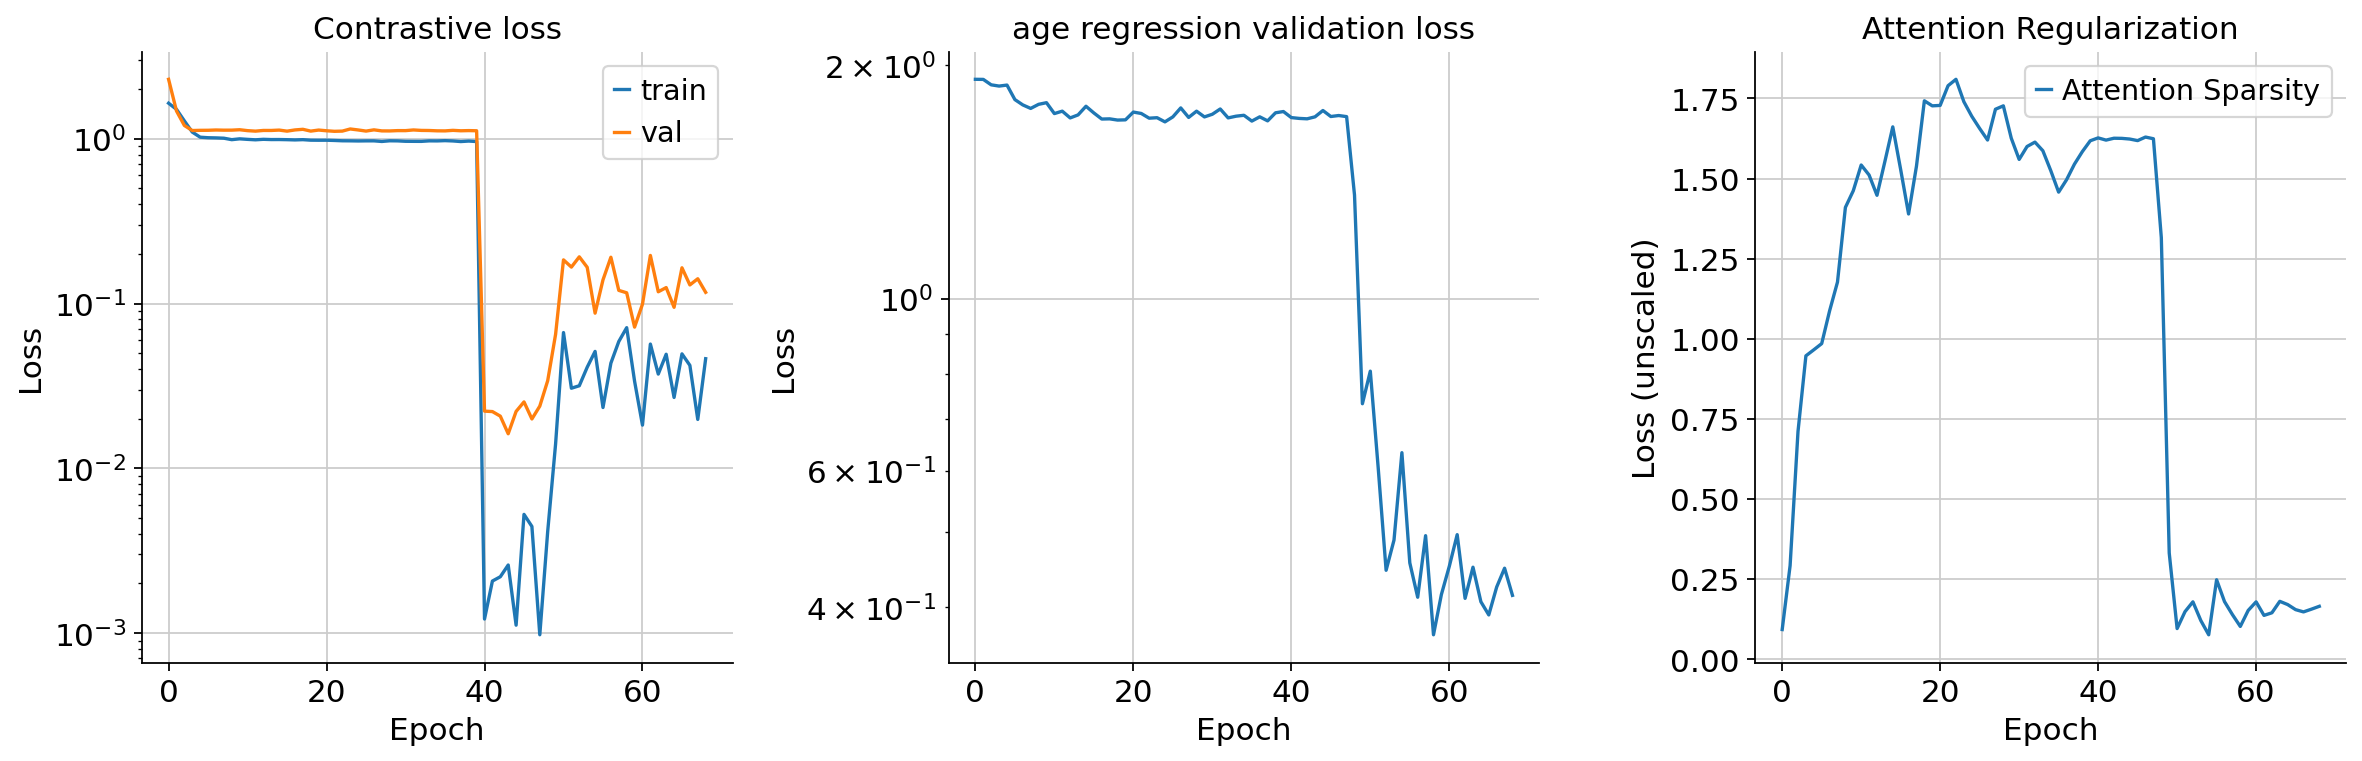

In [15]:
plot_losses(sclr_model);

## Method 5 — PaSCient

A cell→patient attention transformer trained end-to-end on continuous age.
PaSCient expects **log-normalised gene expression**, so we feed it `adata.X`
(HVG, log-normalised) directly rather than the PCA embedding the other methods
consume. Two guardrails for the regression setup:

- `tasks=["regression"]` (the patpy wrapper swaps in MSELoss and z-scores the
  target so the loss doesn't explode against raw ages);
- `normalize=False`: `adata.X` is already log-normalised, so PaSCient must not
  log-transform it a second time.

We read predictions straight from PaSCient's native regression head via
`predict("age")`. PaSCient is GPU-preferred; it falls back to CPU but takes
5-10× longer.


In [16]:
def fit_pascient(adata, train_donors):
    """Train PaSCient on the TRAIN donors only (all of their cells)."""
    train_adata = adata[adata.obs["donor"].astype(str).isin(set(map(str, train_donors)))].copy()
    cells_per_donor = max(1, train_adata.n_obs // max(1, train_adata.obs["donor"].nunique()))
    pascient = patpy.tl.PaSCient(
        sample_key="donor",
        label_keys=["age"],
        tasks=["regression"],
        cell_group_key="AIFI_L2",
        layer=None,                # adata.X holds log-normalised counts — PaSCient's expected input
        n_cells=min(TRAIN_BAG_SIZE, cells_per_donor),
        batch_size=32,
        n_epochs=2 if SMOKE else 30,
        device="cuda" if torch.cuda.is_available() else "cpu",
        normalize=False,           # already log-normalised; don't log() a second time
        seed=SEED,
    )
    pascient.prepare_anndata(train_adata, train=True)
    return pascient


def _compute_pascient():
    pascient = fit_pascient(adata, train_donors)
    # Embedding over ALL donors (encoder trained on train donors) — for the grid.
    all_donors = list(pd.unique(adata.obs["donor"].astype(str)))
    pascient_predict_on(pascient, adata)            # re-extracts embeddings for all donors
    emb = pascient.get_sample_representations().loc[all_donors]
    dist = squareform(pdist(emb.values, metric="euclidean")).astype(np.float32)
    # Held-out evaluation: predict the val donors with PaSCient's native age head.
    val_adata = adata[adata.obs["donor"].astype(str).isin(set(map(str, val_donors)))].copy()
    age_pred = pascient_predict_on(pascient, val_adata)
    score = patpy.tl.evaluate_regression(
        donor_meta["age"].reindex(age_pred.index.astype(str)).astype(float).values, age_pred.values)
    return {"emb": emb, "dist": dist, "score": score}


t0 = time.time()
_pa = load_or_compute_slow("pascient", _compute_pascient)
emb_pa, dist_pa, score_pa = _pa["emb"], _pa["dist"], _pa["score"]
print(f"PaSCient: {time.time() - t0:.1f}s  Pearson r={score_pa['pearson']:.3f}  "
      f"Spearman={score_pa['spearman']:.3f}  MAE={score_pa['mae']:.2f}")

[pascient] loaded cached results from pascient.pkl (set FORCE_RECOMPUTE=True to redo)
PaSCient: 0.0s  Pearson r=0.704  Spearman=0.706  MAE=8.64


## Method 6 — MixMIL

Mixed model + multiple instance learning. The upstream `mixmil` library only
offers binomial / categorical likelihoods, so its native head is trained on the
binary `age_group = age >= 65`. To get a *continuous* age prediction we attach a
regression **linear probe** on top of MixMIL's donor embedding
(`fit_linear_probe("age", task="regression", store=True)`) and read it back
through the same `predict("age")` interface used by the other supervised methods.
The probe is fit on the train donors and scored on the held-out donors.


In [17]:
def fit_mixmil(adata, train_donors):
    """Train MixMIL on the TRAIN donors only (all of their cells)."""
    train_adata = adata[adata.obs["donor"].astype(str).isin(set(map(str, train_donors)))].copy()
    mixmil = patpy.tl.MixMIL(
        sample_key="donor",
        label_keys=["age_group"],
        tasks=["classification"],
        cell_group_key="AIFI_L2",
        layer="X_pca",
        likelihood="binomial",
        n_trials=2,
        n_epochs=200 if SMOKE else 500,   # 500 is plenty; 1500 ran far too long
        batch_size=32,
        seed=SEED,
    )
    mixmil.prepare_anndata(train_adata, train=True)
    return mixmil


def _compute_mixmil():
    mixmil = fit_mixmil(adata, train_donors)
    # MixMIL's native likelihood is binomial, so it cannot regress continuous age.
    # Train a regression linear probe on the TRAIN donors' embeddings (empty test
    # set = fit on all train donors), then evaluate it on the held-out val donors.
    mixmil.fit_linear_probe("age", task="regression", test_sample_labels=[], store=True)
    all_donors = list(pd.unique(adata.obs["donor"].astype(str)))
    mixmil.prepare_anndata(adata, train=False)
    emb = mixmil.get_sample_representations().loc[all_donors]
    dist = squareform(pdist(emb.values, metric="euclidean")).astype(np.float32)
    val_adata = adata[adata.obs["donor"].astype(str).isin(set(map(str, val_donors)))].copy()
    mixmil.prepare_anndata(val_adata, train=False)
    age_pred = mixmil.predict("age")
    score = patpy.tl.evaluate_regression(
        donor_meta["age"].reindex(age_pred.index.astype(str)).astype(float).values, age_pred.values)
    return {"emb": emb, "dist": dist, "score": score}


t0 = time.time()
_mm = load_or_compute_slow("mixmil", _compute_mixmil)
emb_mm, dist_mm, score_mm = _mm["emb"], _mm["dist"], _mm["score"]
print(f"MixMIL: {time.time() - t0:.1f}s  Pearson r={score_mm['pearson']:.3f}  "
      f"Spearman={score_mm['spearman']:.3f}  MAE={score_mm['mae']:.2f}")

[mixmil] loaded cached results from mixmil.pkl (set FORCE_RECOMPUTE=True to redo)
MixMIL: 0.1s  Pearson r=0.521  Spearman=0.544  MAE=9.57


## Method 7 — PULSAR (UCE foundation-model embeddings)

PULSAR is a pretrained foundation model that turns per-cell
[UCE](https://github.com/snap-stanford/UCE) embeddings into a donor-level
representation — no training on this cohort. We load an AIFI AnnData carrying
UCE cell embeddings in ``obsm["X_uce"]``, run PULSAR to get the donor embedding,
and score age with the same linear probe as the other methods. Because UCE is a
cross-cohort embedding, PULSAR's donor space is comparable across datasets out of
the box.

We compare two checkpoints: the default ``KuanP/pulsar-pbmc`` and a cross-cohort ``KuanP/PULSAR-aligned`` model, trained so donor embeddings from different cohorts share one coordinate frame.


In [18]:
AIFI_UCE_PATH = ("/ictstr01/groups/luckylab/workspace/vladimir.shitov/"
                 "2023_05_patient_representation_benchmark/reproducibility/"
                 "pat_rep_benchmark/data/imm_of_aging/imm_of_aging_with_uce_orig.h5ad")


def load_aging_uce(smoke=False, n_donors=20, seed=SEED):
    """AIFI cohort with UCE cell embeddings in obsm['X_uce'] (same obs schema as the main cohort)."""
    adata_uce = add_clean_obs(ad.read_h5ad(AIFI_UCE_PATH))
    if smoke:
        adata_uce = smoke_subset(adata_uce, n_donors=n_donors, seed=seed)
    return adata_uce


def run_pulsar(adata_uce, pretrained_model, label):
    """Fit a (zero-shot) PULSAR variant and return (model, embedding, distances, score).

    Two checkpoints are compared: the default ``KuanP/pulsar-pbmc`` and the
    cross-cohort ``KuanP/PULSAR-aligned`` (trained so embeddings from different
    cohorts share a coordinate frame). Both run on the same UCE input. The probe
    is trained on the shared train donors and scored on the held-out val donors.
    """
    model = patpy.tl.PULSAR(
        sample_key="donor",
        label_keys=["age"],
        tasks=["regression"],
        layer="X_uce",
        pretrained_model=pretrained_model,
        device="cuda" if torch.cuda.is_available() else "cpu",
        seed=SEED,
    )
    model.prepare_anndata(adata_uce)
    embedding = model.get_sample_representations()
    distances = squareform(pdist(embedding.values, metric="euclidean")).astype(np.float32)
    # Use the shared split, restricted to the donors present in the UCE cohort.
    uce_donors = set(embedding.index.astype(str))
    val_ids = [d for d in map(str, val_donors) if d in uce_donors]
    score = model.fit_linear_probe("age", task="regression", test_sample_labels=val_ids)
    print(f"{label}: Pearson r={score['pearson']:.3f}  Spearman={score['spearman']:.3f}  MAE={score['mae']:.2f}")
    # Free the GPU model; the embedding + probe are already cached on the instance.
    model._pulsar_model = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model, embedding, distances, score


t0 = time.time()
adata_uce = load_aging_uce(smoke=SMOKE)
print(f"AIFI+UCE: n_cells={adata_uce.n_obs:,}  n_donors={adata_uce.obs['donor'].nunique()}  loaded in {time.time() - t0:.1f}s")

pulsar, emb_pulsar, dist_pulsar, score_pulsar = run_pulsar(adata_uce, "KuanP/pulsar-pbmc", "PULSAR")
pulsar_aligned, emb_pulsar_aligned, dist_pulsar_aligned, score_pulsar_aligned = run_pulsar(
    adata_uce, "KuanP/PULSAR-aligned", "PULSAR aligned")
print(f"PULSAR variants done in {time.time() - t0:.1f}s")

AIFI+UCE: n_cells=239,616  n_donors=234  loaded in 8.7s


Resample 0 time


PULSAR: Pearson r=0.709  Spearman=0.700  MAE=8.17


Resample 0 time


PULSAR aligned: Pearson r=0.722  Spearman=0.709  MAE=8.04


PULSAR variants done in 28.6s


## Cross-method comparison on the aging cohort

                pearson  spearman    mae
pseudobulk        0.643     0.661  8.885
composition       0.742     0.764  7.162
gloscope          0.529     0.465  9.834
sampleclr-SSL     0.653     0.654  9.159
sampleclr-FT      0.757     0.750  7.788
pascient          0.704     0.706  8.645
mixmil            0.521     0.544  9.569
PULSAR            0.709     0.700  8.165
PULSAR aligned    0.722     0.709  8.039


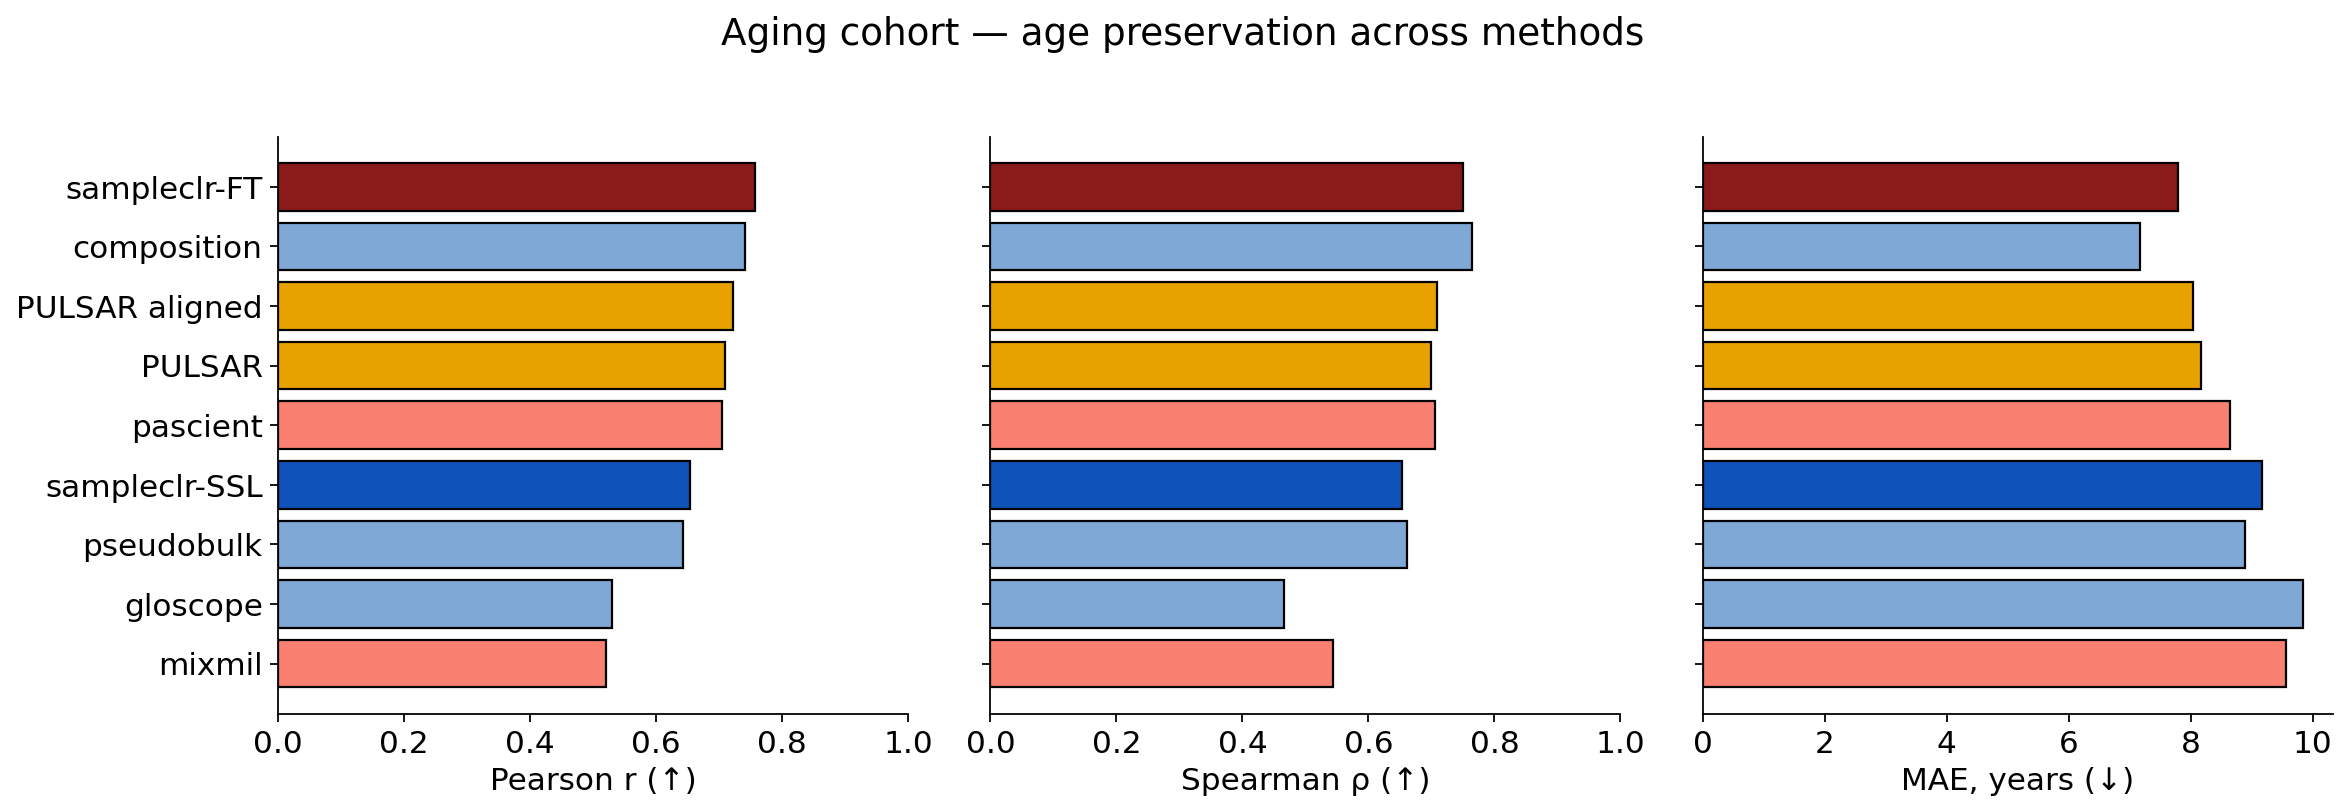

In [19]:
# All methods are scored on held-out donors with the same regression metrics.
# Each score is a result dict (from fit_linear_probe or evaluate_regression); we
# keep just the three comparison metrics.
METRICS = ["pearson", "spearman", "mae"]
method_scores = {
    "pseudobulk": score_pb,
    "composition": score_comp,
    "gloscope": score_gs,
    "sampleclr-SSL": score_ssl,
    "sampleclr-FT": score_ft,
    "pascient": score_pa,
    "mixmil": score_mm,
    "PULSAR": score_pulsar,
    "PULSAR aligned": score_pulsar_aligned,
}
aging_scores = pd.DataFrame(
    {name: {metric: scores[metric] for metric in METRICS} for name, scores in method_scores.items()}
).T
print(aging_scores.round(3))

order = aging_scores.sort_values("pearson", ascending=False).index.tolist()
plot_scores = aging_scores.reindex(order)
colors = [method_color(m) for m in plot_scores.index]

# All three metrics; lower bound 0 so negative values simply fall off the axis.
metrics = [("pearson", "Pearson r (↑)", (0, 1)), ("spearman", "Spearman ρ (↑)", (0, 1)), ("mae", "MAE, years (↓)", (0, None))]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, (col, label, xlim) in zip(axes, metrics):
    ax.barh(plot_scores.index, plot_scores[col], color=colors, edgecolor="black")
    ax.set_xlabel(label)
    ax.set_xlim(*xlim)
    despine(ax)
axes[0].invert_yaxis()
fig.suptitle("Aging cohort — age preservation across methods", y=1.02)
plt.tight_layout(); save_and_show("method_comparison")

## Sample-level embeddings in one AnnData

Each sample-representation method produces a per-donor embedding and a
donor–donor distance matrix. Bundling all of them into a single
**meta_adata** (donors × pseudobulk genes) lets us inspect them
together: a `sc.pp.neighbors` graph per method, a 2-D UMAP per method,
and donor metadata + cell-type compositions sitting in `.obs`.

- ``.X``   — pseudobulk gene expression (mean of cells, log-normalised)
- ``.obsm["X_pb_<cell_type>"]`` — per-cell-type pseudobulk gene expression
- ``.obs``   — donor metadata + per-cell-type fractions (``frac_<cell_type>``)
- ``.obsm[method_name]`` / ``.obsm[method_name+"_distances"]`` / ``.obsm["X_umap_"+method_name]``
  — sample representation, donor–donor distance, UMAP coords for each method
- ``.uns["sample_representations"]`` lists the method names


In [20]:
# --- Build the donor-level meta AnnData from patpy aggregation primitives ---
# Donor pseudobulk over genes (Pseudobulk), per-cell-type pseudobulks
# (GroupedPseudobulk) and cell-type composition (patpy.pp) — no hand-rolled loops.
pb_genes = patpy.tl.Pseudobulk(sample_key="donor", cell_group_key="AIFI_L2", layer="X", seed=SEED)
pb_genes.prepare_anndata(adata)
pb_genes.calculate_distance_matrix()
donors_pb = [str(s) for s in pb_genes.samples]
bulk_X = np.asarray(pb_genes.sample_representation, dtype=np.float32)

grouped = patpy.tl.GroupedPseudobulk(sample_key="donor", cell_group_key="AIFI_L2", layer="X", seed=SEED)
grouped.prepare_anndata(adata)
grouped.calculate_distance_matrix()
# sample_representation is (n_cell_groups, n_donors, n_genes); reorder donors to match pb_genes.
grouped_samples = [str(s) for s in grouped.samples]
donor_order = [grouped_samples.index(donor) for donor in donors_pb]
celltype_bulks = np.asarray(grouped.sample_representation, dtype=np.float32)[:, donor_order, :]

meta_adata = ad.AnnData(X=bulk_X)
meta_adata.var_names = adata.var_names.astype(str)
meta_adata.obs_names = pd.Index(donors_pb)
meta_adata.obs = donor_meta.loc[donors_pb].copy()

for cell_type, celltype_means in zip(grouped.cell_groups, celltype_bulks):
    key = "X_pb_" + str(cell_type).replace(" ", "_").replace("/", "_")
    meta_adata.obsm[key] = np.nan_to_num(celltype_means, nan=0.0)

# Cell-type composition (per-donor fractions) via patpy.pp.
fractions = patpy.pp.calculate_compositional_metrics(
    adata, sample_key="donor", composition_keys=["AIFI_L2"], normalize_to=1
).reindex(donors_pb).fillna(0.0).astype(np.float32)
fractions.columns = ["frac_" + str(c).replace("AIFI_L2_", "").replace(" ", "_").replace("/", "_")
                     for c in fractions.columns]
meta_adata.obs = pd.concat([meta_adata.obs, fractions], axis=1)
print(meta_adata)


AnnData object with n_obs × n_vars = 234 × 4000
    obs: 'age', 'age_group', 'sex', 'cmv', 'race', 'batch', 'pool', 'chip', 'n_cells', 'age_decade', 'frac_ASDC', 'frac_CD8aa', 'frac_CD14_monocyte', 'frac_CD16_monocyte', 'frac_CD56bright_NK_cell', 'frac_CD56dim_NK_cell', 'frac_DN_T_cell', 'frac_Effector_B_cell', 'frac_Erythrocyte', 'frac_ILC', 'frac_MAIT', 'frac_Memory_B_cell', 'frac_Memory_CD4_T_cell', 'frac_Memory_CD8_T_cell', 'frac_Naive_B_cell', 'frac_Naive_CD4_T_cell', 'frac_Naive_CD8_T_cell', 'frac_Plasma_cell', 'frac_Platelet', 'frac_Progenitor_cell', 'frac_Proliferating_NK_cell', 'frac_Proliferating_T_cell', 'frac_Transitional_B_cell', 'frac_Treg', 'frac_cDC1', 'frac_cDC2', 'frac_gdT', 'frac_pDC'
    obsm: 'X_pb_Memory_B_cell', 'X_pb_Transitional_B_cell', 'X_pb_Plasma_cell', 'X_pb_Effector_B_cell', 'X_pb_Naive_B_cell', 'X_pb_Treg', 'X_pb_Memory_CD4_T_cell', 'X_pb_Proliferating_T_cell', 'X_pb_Naive_CD4_T_cell', 'X_pb_Memory_CD8_T_cell', 'X_pb_gdT', 'X_pb_CD8aa', 'X_pb_MAIT', 'X_p

In [21]:
# --- Adapter to plug an externally-fitted method into meta_adata. ---
# Mirrors patpy's `store_representation` but takes the embedding, distance matrix
# and sample order directly (so the fit_* cells above don't need to return the
# model object). UMAPs are computed with scanpy from the precomputed distances.


def store_representation(meta_adata, sample_representation, distances, samples, method_name, seed=SEED):
    representation = np.asarray(sample_representation, dtype=np.float32)
    distances = np.asarray(distances, dtype=np.float32)
    samples = [str(s) for s in samples]
    obs_names = list(meta_adata.obs_names.astype(str))

    position_of_sample = {sample: i for i, sample in enumerate(samples)}
    missing = [name for name in obs_names if name not in position_of_sample]
    if missing:
        raise RuntimeError(
            f"method {method_name!r} is missing {len(missing)} donors "
            f"(first few: {missing[:3]}). Make sure prepare_anndata was called on the full cohort."
        )
    order = np.array([position_of_sample[name] for name in obs_names])
    meta_adata.obsm[method_name] = representation[order]
    meta_adata.obsm[f"{method_name}_distances"] = distances[np.ix_(order, order)]

    # Neighbours graph + UMAP from the precomputed donor-donor distances, via scanpy.
    n_neighbors = min(15, len(obs_names) - 1)
    sc.pp.neighbors(meta_adata, use_rep=f"{method_name}_distances", metric="precomputed",
                    n_neighbors=n_neighbors, key_added=f"{method_name}_neighbors")
    sc.tl.umap(meta_adata, neighbors_key=f"{method_name}_neighbors", min_dist=0.3, random_state=seed)
    meta_adata.obsm[f"X_umap_{method_name}"] = meta_adata.obsm.pop("X_umap").astype(np.float32)

    meta_adata.uns.setdefault("sample_representations", [])
    if method_name not in meta_adata.uns["sample_representations"]:
        meta_adata.uns["sample_representations"].append(method_name)
    return meta_adata


# Each method's (embedding, distance, sample-order) tuple from the cells above.
method_blobs = [
    ("pseudobulk",    emb_pb.values,   dist_pb,   list(emb_pb.index)),
    ("composition",   emb_comp.values, dist_comp, list(emb_comp.index)),
    ("gloscope",      emb_gs.values,   dist_gs,   list(emb_gs.index)),
    ("sampleclr_ssl", emb_ssl.values,  dist_ssl,  list(emb_ssl.index)),
    ("sampleclr_ft",  emb_ft.values,   dist_ft,   list(emb_ft.index)),
    ("pascient",      emb_pa.values,   dist_pa,   list(emb_pa.index)),
    ("mixmil",        emb_mm.values,   dist_mm,   list(emb_mm.index)),
]
for method_name, representation, distances, samples in method_blobs:
    store_representation(meta_adata, representation, distances, samples, method_name)
print("stored:", meta_adata.uns["sample_representations"])


# --- PULSAR variants run on their own UCE donor set; add them to the grid too. ---
def store_pulsar_umap(meta_adata, embedding_df, method_name, seed=SEED, min_donors=5):
    """Store a PULSAR-style embedding that may cover only a subset of meta donors.

    PULSAR is fitted on the UCE cohort, whose donor set need not exactly match the
    main cohort. Donors absent from the embedding get NaN UMAP coordinates and
    simply don't appear in the grid scatter. The UMAP is computed with scanpy on
    the covered-donor sub-embedding.
    """
    obs_names = list(meta_adata.obs_names.astype(str))
    emb = embedding_df.copy()
    emb.index = emb.index.astype(str)
    covered = [donor for donor in obs_names if donor in emb.index]
    if len(covered) < min_donors:
        print(f"{method_name}: only {len(covered)} donors overlap meta_adata - skipping UMAP")
        return meta_adata

    sub = emb.loc[covered].values.astype(np.float32)
    sub_adata = ad.AnnData(X=sub)
    sub_adata.obs_names = covered
    n_neighbors = min(15, len(covered) - 1)
    sc.pp.neighbors(sub_adata, use_rep="X", n_neighbors=n_neighbors)
    sc.tl.umap(sub_adata, min_dist=0.3, random_state=seed)
    coords_sub = sub_adata.obsm["X_umap"]

    position = {donor: i for i, donor in enumerate(obs_names)}
    coords = np.full((meta_adata.n_obs, 2), np.nan, dtype=np.float32)
    full_emb = np.full((meta_adata.n_obs, sub.shape[1]), np.nan, dtype=np.float32)
    for j, donor in enumerate(covered):
        coords[position[donor]] = coords_sub[j]
        full_emb[position[donor]] = sub[j]
    meta_adata.obsm[f"X_umap_{method_name}"] = coords
    meta_adata.obsm[method_name] = full_emb

    meta_adata.uns.setdefault("sample_representations", [])
    if method_name not in meta_adata.uns["sample_representations"]:
        meta_adata.uns["sample_representations"].append(method_name)
    print(f"{method_name}: {len(covered)}/{len(obs_names)} donors covered")
    return meta_adata


store_pulsar_umap(meta_adata, emb_pulsar, "pulsar")
store_pulsar_umap(meta_adata, emb_pulsar_aligned, "pulsar_aligned")
print("stored (with PULSAR):", meta_adata.uns["sample_representations"])

stored: ['pseudobulk', 'composition', 'gloscope', 'sampleclr_ssl', 'sampleclr_ft', 'pascient', 'mixmil']


pulsar: 234/234 donors covered


pulsar_aligned: 234/234 donors covered
stored (with PULSAR): ['pseudobulk', 'composition', 'gloscope', 'sampleclr_ssl', 'sampleclr_ft', 'pascient', 'mixmil', 'pulsar', 'pulsar_aligned']


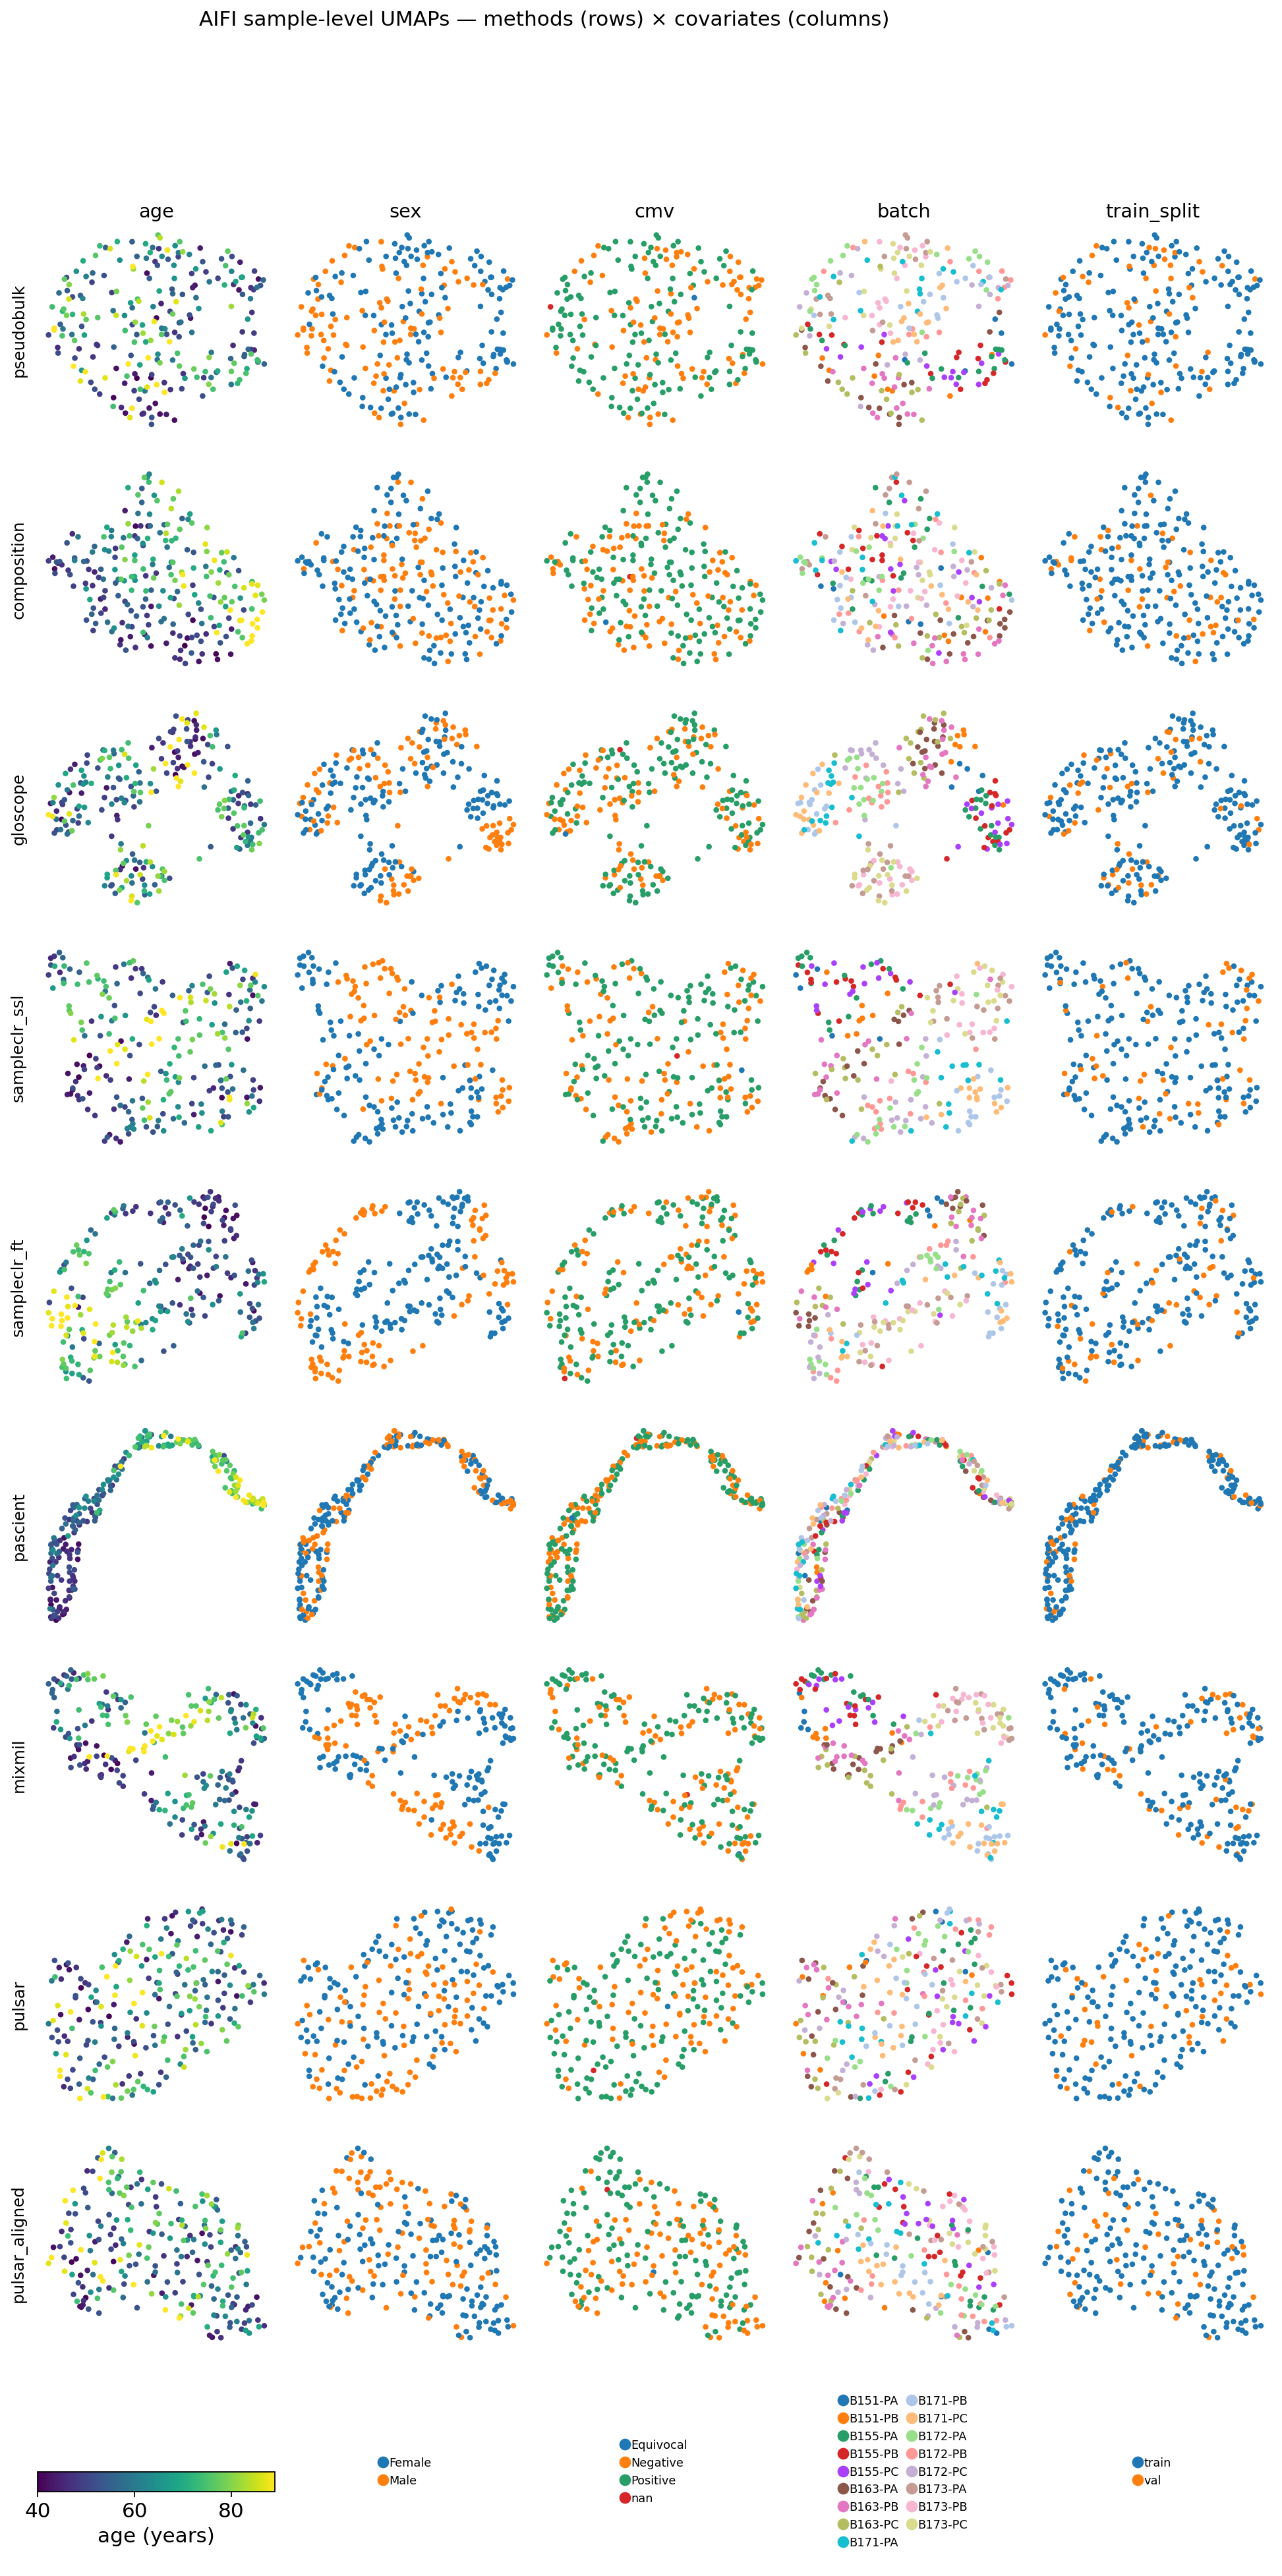

In [22]:
# Sample-level UMAP grid drawn with scanpy: methods (rows) x covariates (columns).
# Colour keys live in their own bottom row so every panel stays the same size and
# nothing overlaps.
import scanpy as sc

val_set = set(map(str, val_donors))
meta_adata.obs["train_split"] = np.where(meta_adata.obs_names.astype(str).isin(val_set), "val", "train")
meta_adata.obs["age"] = meta_adata.obs["age"].astype(float)
for covariate in ["sex", "cmv", "batch", "train_split"]:
    meta_adata.obs[covariate] = meta_adata.obs[covariate].astype(str).astype("category")

methods = list(meta_adata.uns["sample_representations"])
covariates = ["age", "sex", "cmv", "batch", "train_split"]
nrows, ncols = len(methods), len(covariates)

fig = plt.figure(figsize=(ncols * 3.0, nrows * 3.0 + 2.2))
gs = fig.add_gridspec(nrows + 1, ncols, height_ratios=[1] * nrows + [0.9], hspace=0.15, wspace=0.05)
axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(ncols)] for r in range(nrows)])
key_axes = [fig.add_subplot(gs[nrows, c]) for c in range(ncols)]

for row, method in enumerate(methods):
    for col, covariate in enumerate(covariates):
        ax = axes[row, col]
        sc.pl.embedding(meta_adata, basis=f"umap_{method}", color=covariate, ax=ax, show=False,
                        frameon=False, size=60, legend_loc="none", colorbar_loc=None, title="")
        if row == 0:
            ax.set_title(covariate, fontsize=13)
    axes[row, 0].annotate(method, xy=(-0.08, 0.5), xycoords="axes fraction",
                          rotation=90, ha="center", va="center", fontsize=11)

# One colour key per column, each confined to its own bottom cell (no overlap).
for col, covariate in enumerate(covariates):
    key_ax = key_axes[col]
    key_ax.axis("off")
    if covariate == "age":
        cbar = fig.colorbar(axes[0, col].collections[0], ax=key_ax, orientation="horizontal",
                            fraction=0.5, aspect=12, pad=0.0)
        cbar.set_label("age (years)")
    else:
        categories = list(meta_adata.obs[covariate].cat.categories)
        colors = meta_adata.uns.get(f"{covariate}_colors")
        if colors is not None and len(categories) <= 20:
            handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
                                  markerfacecolor=colors[k % len(colors)], markeredgecolor="none", label=str(name))
                       for k, name in enumerate(categories)]
            key_ax.legend(handles=handles, loc="center", frameon=False, fontsize=8,
                          ncol=1 if len(categories) <= 5 else 2,
                          handletextpad=0.3, columnspacing=0.8, borderaxespad=0.0)

fig.suptitle("AIFI sample-level UMAPs — methods (rows) × covariates (columns)", fontsize=14)
save_and_show("umap_grid")


### Persist `meta_adata` to disk

All seven sample representations are now bundled into a single
``AnnData``. Writing it to a single `.h5ad` makes the downstream
analyses (biology, sweep, attention) and any future post-hoc work
fast to resume — no need to re-fit every method.


In [23]:
import os
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

# Persist meta_adata: every method's sample representation, distances, UMAP and
# the donor-level pseudobulk / per-cell-type pseudobulk all live in one file.
META_ADATA_DIR = ARTIFACT_DIR
META_ADATA_DIR.mkdir(parents=True, exist_ok=True)
META_ADATA_PATH = META_ADATA_DIR / "aifi_meta_adata.h5ad"

# obs columns with the categorical dtype "category" sometimes need flattening
# for h5ad to accept them. Pre-cast object dtypes to string.
for col in meta_adata.obs.columns:
    if meta_adata.obs[col].dtype == object:
        meta_adata.obs[col] = meta_adata.obs[col].astype(str)

meta_adata.write_h5ad(META_ADATA_PATH)
print(f"meta_adata -> {META_ADATA_PATH}  ({META_ADATA_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"  obs: {list(meta_adata.obs.columns)[:10]}{'...' if meta_adata.obs.shape[1] > 10 else ''}")
print(f"  obsm: {list(meta_adata.obsm.keys())[:8]}{'...' if len(meta_adata.obsm) > 8 else ''}")
print(f"  representations: {meta_adata.uns['sample_representations']}")


meta_adata -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts/aifi_meta_adata.h5ad  (112.7 MB)
  obs: ['age', 'age_group', 'sex', 'cmv', 'race', 'batch', 'pool', 'chip', 'n_cells', 'age_decade']...
  obsm: ['X_pb_Memory_B_cell', 'X_pb_Transitional_B_cell', 'X_pb_Plasma_cell', 'X_pb_Effector_B_cell', 'X_pb_Naive_B_cell', 'X_pb_Treg', 'X_pb_Memory_CD4_T_cell', 'X_pb_Proliferating_T_cell']...
  representations: ['pseudobulk', 'composition', 'gloscope', 'sampleclr_ssl', 'sampleclr_ft', 'pascient', 'mixmil', 'pulsar', 'pulsar_aligned']


## Biology: which cell types correlate with age?

Composition (CLR) ignores expression entirely — yet it reaches the
strongest unsupervised score on this cohort. So most of the
predictable variance must live in the cell-type fractions themselves.
We Pearson-correlate each per-donor cell-type fraction with age.

Top cell types DECREASING with age (AIFI):
                      r    p
Naive CD8 T cell -0.615  0.0
CD8aa            -0.415  0.0
MAIT             -0.344  0.0
ILC              -0.250  0.0
Memory B cell    -0.242  0.0

Top cell types INCREASING with age (AIFI):
                       r      p
Platelet           0.123  0.060
Effector B cell    0.123  0.060
Memory CD4 T cell  0.136  0.037
Memory CD8 T cell  0.162  0.013
CD56dim NK cell    0.175  0.007


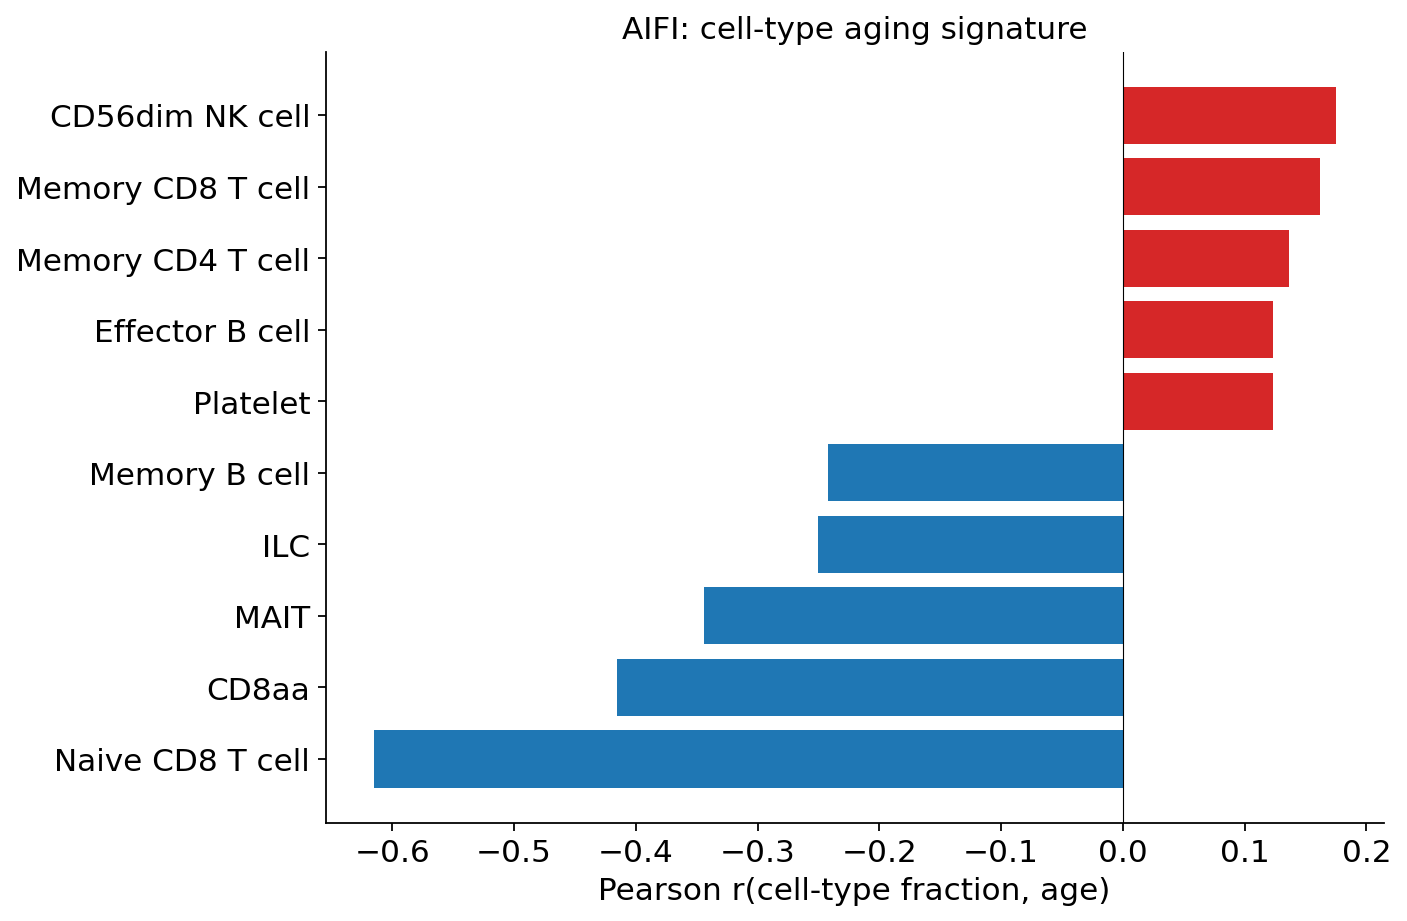

In [24]:
# Pearson-correlate each per-donor cell-type fraction with age.
fractions_with_age = celltype_fractions.join(donor_meta["age"])
ages = fractions_with_age.pop("age")
corr_aging = fractions_with_age.apply(
    lambda fraction: pd.Series({"r": pearsonr(fraction, ages)[0], "p": pearsonr(fraction, ages)[1]})
).T.sort_values("r")
print("Top cell types DECREASING with age (AIFI):")
print(corr_aging.head(5).round(3))
print("\nTop cell types INCREASING with age (AIFI):")
print(corr_aging.tail(5).round(3))

fig, ax = plt.subplots(figsize=(9, 6))
top = pd.concat([corr_aging.head(5), corr_aging.tail(5)])
ax.barh(top.index, top["r"], color=["#1f77b4" if r < 0 else "#d62728" for r in top["r"]])
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Pearson r(cell-type fraction, age)")
ax.set_title("AIFI: cell-type aging signature")
despine(ax)
plt.tight_layout(); save_and_show("celltype_aging_signature")


### Genes correlated with age (pseudobulk-level)

The pseudobulk method computes a donor-level mean of the per-cell `X_pca`
embedding. To go back to gene resolution we do the same averaging at the
expression level: per donor, take the mean log-normalised expression of
every gene, then Pearson-correlate each gene's vector across donors with
age. These are the genes whose **donor-mean expression shifts with age**,
i.e. the gene-level aging signature that the pseudobulk distance is
implicitly leveraging.

In [25]:
# Pseudobulk gene expression per donor (mean of cells in log-normalised space),
# then Pearson-correlate each gene's donor-vector with age.
# Reuse the donor x gene pseudobulk already in meta_adata.X (patpy Pseudobulk).
bulk_aging = pd.DataFrame(np.asarray(meta_adata.X), index=meta_adata.obs_names.astype(str),
                          columns=meta_adata.var_names.astype(str))
print(f"pseudobulk matrix: {bulk_aging.shape}  (donors x genes)")

# pandas aligns on the donor index and skips donors with missing age, then
# Pearson-correlates every gene's donor-vector with age in one call.
age = donor_meta["age"].reindex(bulk_aging.index).astype(float)
gene_age_corr = bulk_aging.corrwith(age, axis=0).rename("r").sort_values()

print("\nTop 10 genes DECREASING with age in AIFI pseudobulk:")
print(gene_age_corr.head(10).round(3))
print("\nTop 10 genes INCREASING with age:")
print(gene_age_corr.tail(10).round(3))

pseudobulk matrix: (234, 4000)  (donors x genes)



Top 10 genes DECREASING with age in AIFI pseudobulk:
ROBO1    -0.606
CD248    -0.565
SFRP5    -0.538
FLNB     -0.506
NT5E     -0.500
LRRN3    -0.482
NRCAM    -0.469
SHANK1   -0.461
MXRA8    -0.414
IGFBP6   -0.404
Name: r, dtype: float64

Top 10 genes INCREASING with age:
CPQ        0.376
RNF149     0.377
KATNAL1    0.392
EDA        0.393
GREM2      0.401
FNDC3B     0.401
UPP1       0.402
PRDM1      0.449
ADGRE5     0.465
INPP4B     0.477
Name: r, dtype: float64


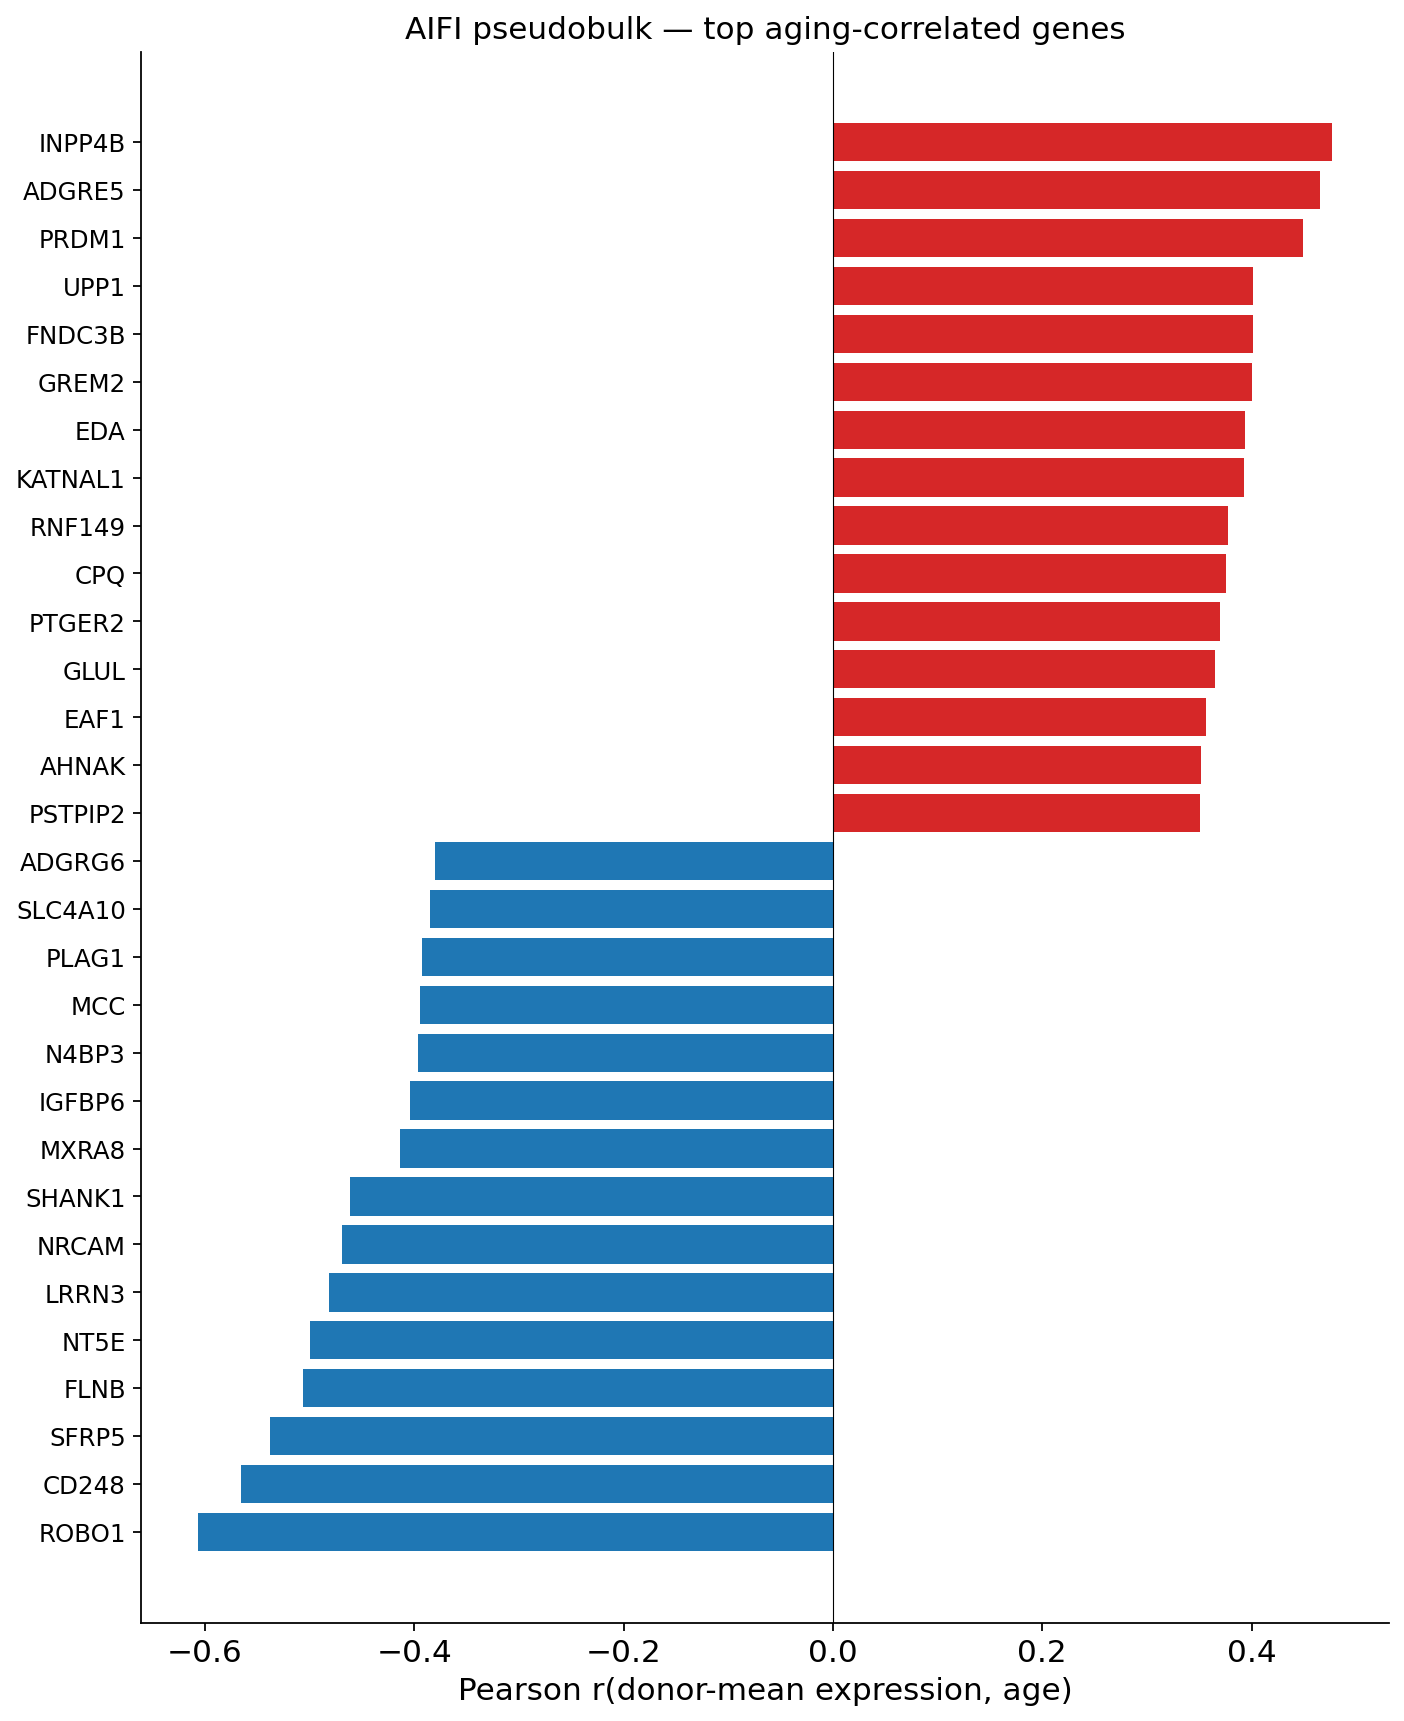

In [26]:
# Top aging-correlated genes. A tall figure + larger tick labels keeps the 30
# gene names from crowding each other.
fig, ax = plt.subplots(figsize=(9, 11))
top = pd.concat([gene_age_corr.head(15), gene_age_corr.tail(15)]).sort_values()
ax.barh(top.index, top.values, color=["#1f77b4" if r < 0 else "#d62728" for r in top.values])
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Pearson r(donor-mean expression, age)")
ax.set_title("AIFI pseudobulk — top aging-correlated genes")
ax.tick_params(axis="y", labelsize=11)
despine(ax)
plt.tight_layout(); save_and_show("top_aging_genes")


### Connecting the PCs back to genes

The pseudobulk distance lives in 50-D `X_pca` space; the methods above
treat each PC as a feature without knowing what biology lives in it. We
can read each PC's "meaning" off its loadings (`adata.varm["PCs"]` — the
eigenvectors that mapped log-normalised gene expression into the 50-D PCA
space).

For each donor-level age-correlated PC, the top-loading genes tell us
what transcriptional program drove that PC.

In [27]:
# Per-donor mean of X_pca = the pseudobulk vector. Correlate each PC with age.
# Reuse the donor x PCA pseudobulk from Method 1 (patpy Pseudobulk).
pca_per_donor = pd.DataFrame(
    np.asarray(emb_pb.values), index=emb_pb.index.astype(str),
    columns=[f"PC{i + 1}" for i in range(emb_pb.shape[1])]
)
age = donor_meta["age"].reindex(pca_per_donor.index).astype(float).values
pc_age_corr = pd.Series(
    [pearsonr(pca_per_donor[pc].values, age)[0] for pc in pca_per_donor.columns],
    index=pca_per_donor.columns, name="r",
).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top 10 PCs by |r(donor-mean PC, age)|:")
print(pc_age_corr.head(10).round(3))


Top 10 PCs by |r(donor-mean PC, age)|:
PC9     0.391
PC28    0.352
PC8    -0.288
PC10   -0.277
PC22   -0.249
PC26   -0.247
PC27   -0.212
PC25   -0.212
PC21    0.206
PC43    0.206
Name: r, dtype: float64


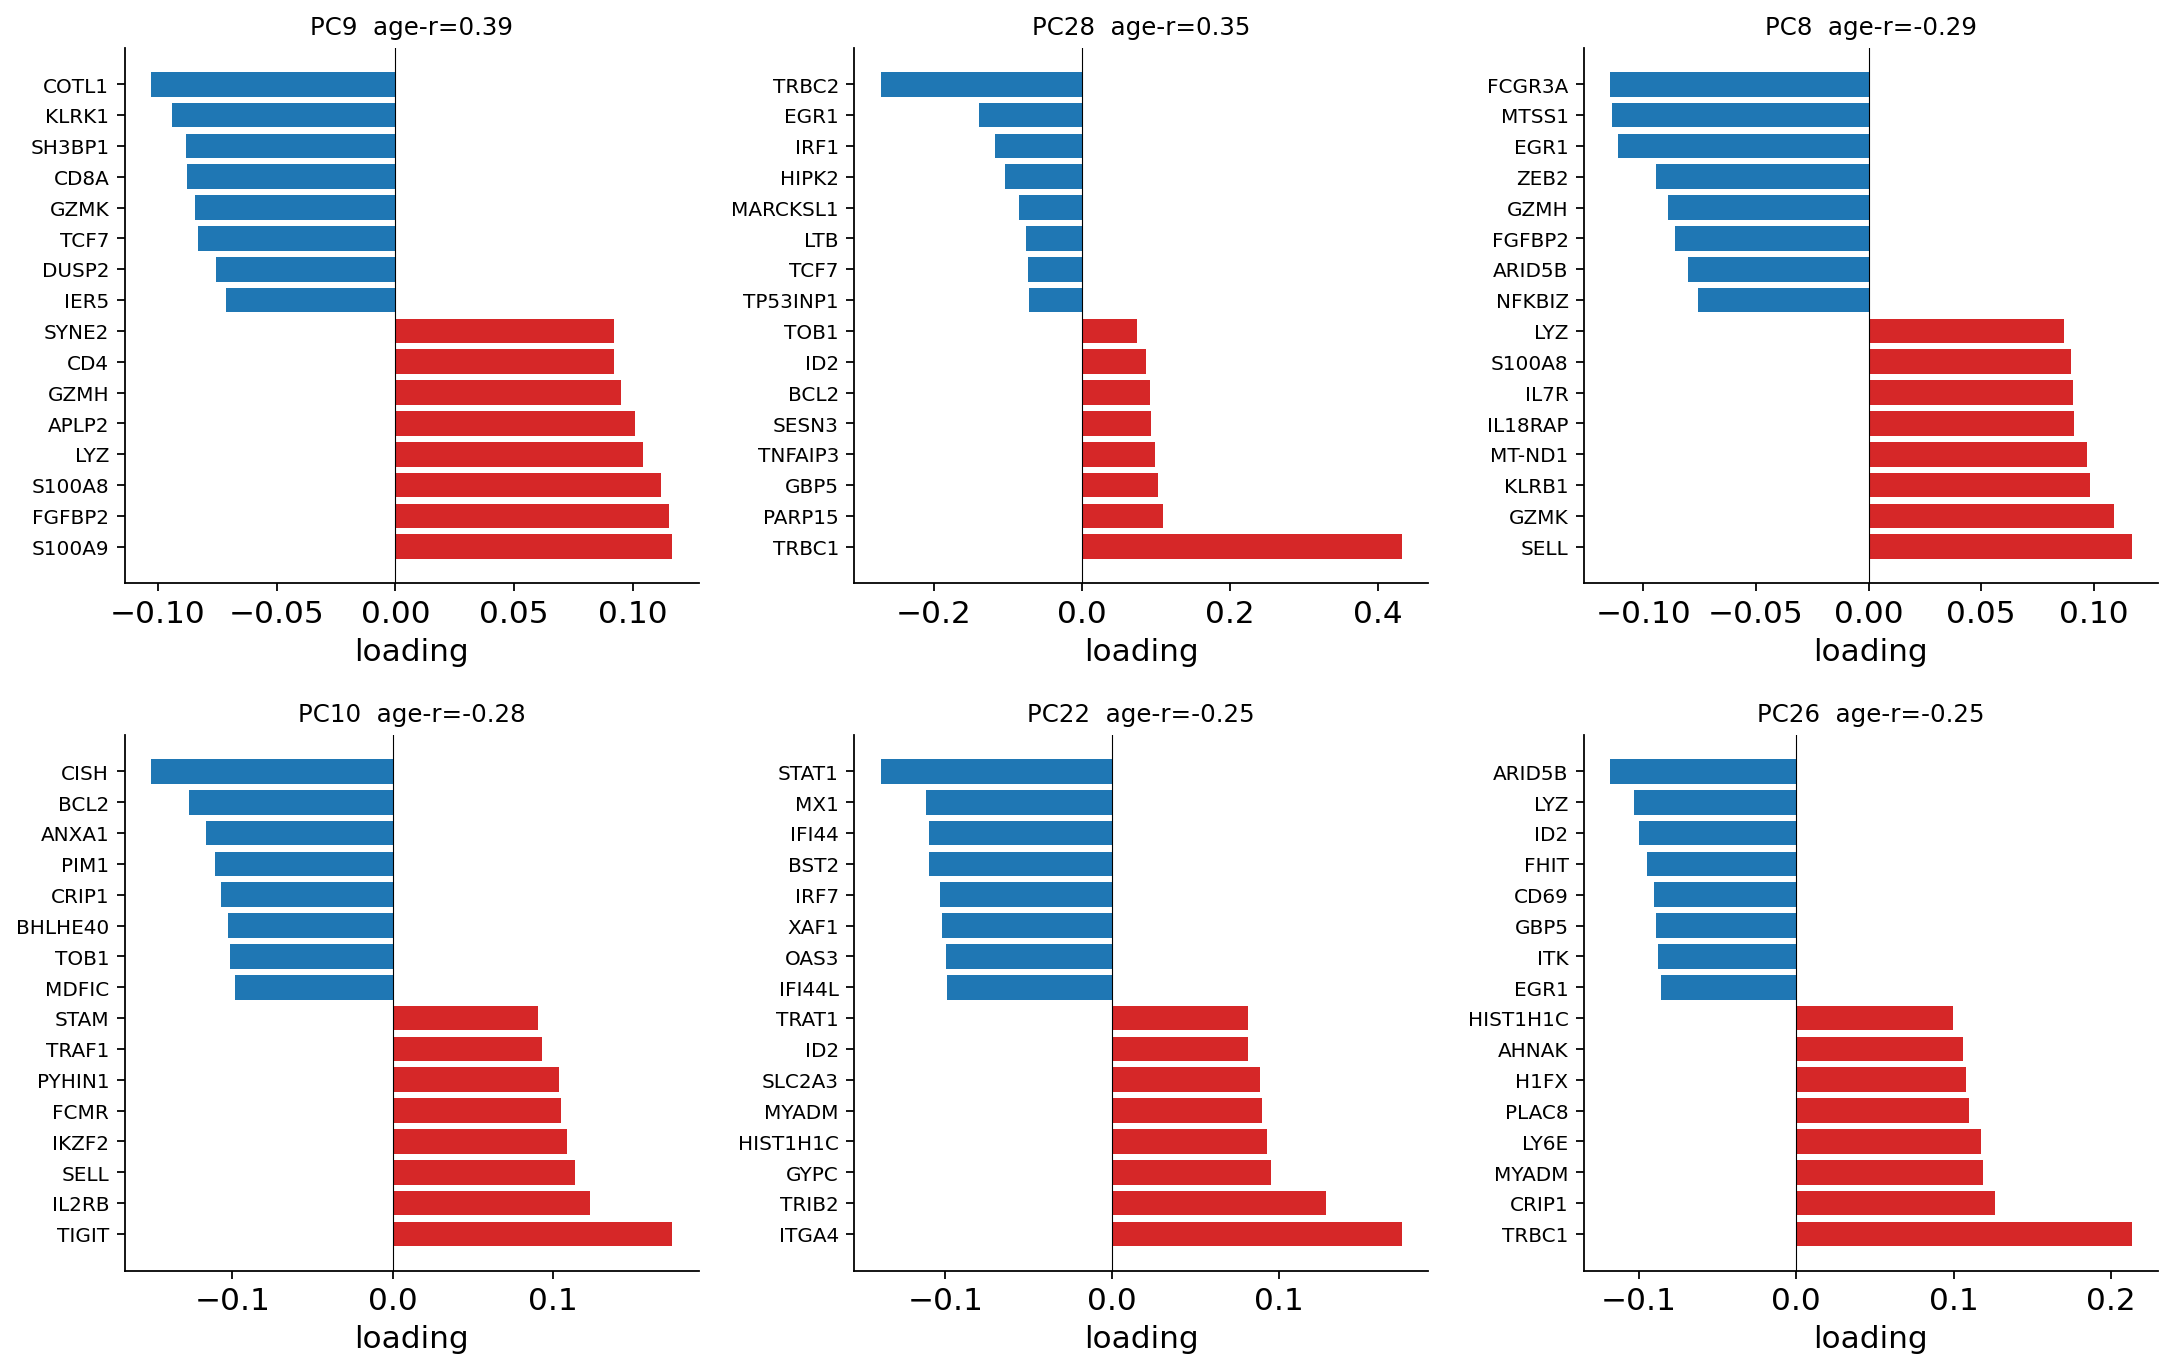

In [28]:
# Read the top-loading genes for the most age-correlated PCs.
loadings = pd.DataFrame(
    adata.varm["PCs"], index=adata.var_names.astype(str),
    columns=[f"PC{i + 1}" for i in range(adata.varm["PCs"].shape[1])],
)

top_pcs = pc_age_corr.head(6).index.tolist()
ncols = 3
nrows = int(np.ceil(len(top_pcs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.6, nrows * 4.4), squeeze=False)
for ax, pc in zip(axes.ravel(), top_pcs):
    loads = loadings[pc].sort_values()
    top_genes = pd.concat([loads.head(8), loads.tail(8)])
    ax.barh(top_genes.index, top_genes.values,
            color=["#1f77b4" if value < 0 else "#d62728" for value in top_genes.values])
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{pc}  age-r={pc_age_corr[pc]:.2f}", fontsize=11)
    ax.set_xlabel("loading")
    ax.tick_params(axis="y", labelsize=9)
    ax.invert_yaxis()
    despine(ax)
for ax in axes.ravel()[len(top_pcs):]:
    ax.set_visible(False)
plt.tight_layout(); save_and_show("pc_gene_loadings")


**Reading the loading plots.** For each of the top age-correlated PCs,
red bars are genes that **load positively** on the PC (cells expressing
them shift the PC value up) and blue bars are genes loading negatively.
Combined with the header's `age-r`:

- A PC with `age-r > 0` whose red bars include cytotoxic markers
  (`GZMB`, `GNLY`, `PRF1`, `NKG7`) tells us: *donors with more cells
  expressing this cytotoxic program score higher on this PC, and that
  PC tracks age*.
- A PC with `age-r < 0` whose red bars include naive T markers
  (`CCR7`, `LEF1`, `TCF7`, `SELL`) tells us the *opposite* — that PC
  encodes naivety, and naivety drops with age.

This is the same biology you'd get from a manual differential test on
pseudobulks, just routed through the PCA the methods actually consume.

## Cross-cohort validation on OneK1K

Same three unsupervised methods + SampleCLR on a 981-donor independent
cohort with age 19–97. If a method captures *aging* and not *AIFI
quirks*, the score on OneK1K should look similar.

In [29]:
def load_onek1k():
    onek1k, _ = patpy.datasets.onek1k(return_dataset_info=True)
    onek1k.obs["donor"] = onek1k.obs["donor_id"].astype(str)
    onek1k.obs["age_group"] = np.where(onek1k.obs["age"] >= 65, "old", "young")
    return onek1k

t0 = time.time()
adata_onek1k = load_onek1k()
if SMOKE:
    adata_onek1k = smoke_subset(adata_onek1k, n_donors=20)
print(f"OneK1K: n_cells={adata_onek1k.n_obs:,}  n_donors={adata_onek1k.obs['donor'].nunique()}  loaded in {time.time()-t0:.1f}s")

OneK1K: n_cells=1,248,980  n_donors=981  loaded in 6.7s


In [30]:
# Cross-cohort: re-fit the two cheap unsupervised methods on OneK1K and score
# age with the same linear probe used on AIFI.
donor_meta_onek1k = adata_onek1k.obs[["donor", "age", "age_group", "sex", "pool_number"]].copy()
donor_meta_onek1k["donor"] = donor_meta_onek1k["donor"].astype(str)
donor_meta_onek1k = donor_meta_onek1k.groupby("donor", observed=True).agg(
    age=("age", "first"), age_group=("age_group", "first"),
    sex=("sex", "first"), pool=("pool_number", "first"),
)

donor_order_onek1k = list(pd.unique(adata_onek1k.obs["donor"].astype(str)))
train_onek1k, test_onek1k = donor_train_val_split(donor_order_onek1k, donor_meta_onek1k["age"], seed=SEED)


def score_unsupervised_onek1k(method):
    """Linear-probe age score on OneK1K, reported for all donors and for age >= 40.

    AIFI only covers ages 40-89, so the ``age >= 40`` slice is the fair
    cross-cohort comparison.
    """
    method.prepare_anndata(adata_onek1k)
    method.calculate_distance_matrix()
    probe = method.fit_linear_probe("age", task="regression", test_sample_labels=test_onek1k)
    y_true = np.asarray(probe["age_test"], dtype=float)
    y_pred = np.asarray(probe["age_pred"], dtype=float)
    over_40 = y_true >= 40
    return (
        patpy.tl.evaluate_regression(y_true, y_pred),
        patpy.tl.evaluate_regression(y_true[over_40], y_pred[over_40]),
    )


score_pb_one_all, score_pb_one_40 = score_unsupervised_onek1k(
    patpy.tl.Pseudobulk(sample_key="donor", cell_group_key="cell_type", layer="X_pca", seed=SEED)
)
score_comp_one_all, score_comp_one_40 = score_unsupervised_onek1k(
    patpy.tl.CellGroupComposition(sample_key="donor", cell_group_key="cell_type", apply_clr=True, seed=SEED)
)

for name, scores_all, scores_40 in [
    ("pseudobulk", score_pb_one_all, score_pb_one_40),
    ("composition", score_comp_one_all, score_comp_one_40),
]:
    print(f"OneK1K {name:<12s} all donors:  Pearson r={scores_all['pearson']:.3f}  Spearman={scores_all['spearman']:.3f}  MAE={scores_all['mae']:.2f}  n={scores_all['n']}")
    print(f"OneK1K {name:<12s} age >= 40:   Pearson r={scores_40['pearson']:.3f}  Spearman={scores_40['spearman']:.3f}  MAE={scores_40['mae']:.2f}  n={scores_40['n']}")
print()
print("OneK1K covers age 19-97; the AIFI cohort only covers 40-89, so the")
print("`age >= 40` row is the fair comparison for cross-cohort transfer.")


OneK1K pseudobulk   all donors:  Pearson r=0.660  Spearman=0.599  MAE=9.92  n=197
OneK1K pseudobulk   age >= 40:   Pearson r=0.495  Spearman=0.475  MAE=8.82  n=174
OneK1K composition  all donors:  Pearson r=0.698  Spearman=0.687  MAE=9.49  n=197
OneK1K composition  age >= 40:   Pearson r=0.547  Spearman=0.579  MAE=8.44  n=174

OneK1K covers age 19-97; the AIFI cohort only covers 40-89, so the
`age >= 40` row is the fair comparison for cross-cohort transfer.


In [31]:
celltype_fractions_onek1k = pd.crosstab(
    adata_onek1k.obs["donor"].astype(str), adata_onek1k.obs["cell_type"].astype(str), normalize="index"
).join(donor_meta_onek1k["age"])
ages_onek1k = celltype_fractions_onek1k.pop("age")
corr_onek1k = celltype_fractions_onek1k.apply(
    lambda fraction: pd.Series({"r": pearsonr(fraction, ages_onek1k)[0], "p": pearsonr(fraction, ages_onek1k)[1]})
).T.sort_values("r")
print("OneK1K — top cell types decreasing with age:")
print(corr_onek1k.head(5).round(3))
print("\nTop cell types increasing with age:")
print(corr_onek1k.tail(5).round(3))


OneK1K — top cell types decreasing with age:
                                                        r    p
naive thymus-derived CD8-positive, alpha-beta T... -0.680  0.0
mucosal invariant T cell                           -0.297  0.0
naive thymus-derived CD4-positive, alpha-beta T... -0.200  0.0
memory B cell                                      -0.153  0.0
central memory CD8-positive, alpha-beta T cell     -0.135  0.0

Top cell types increasing with age:
                                                     r      p
central memory CD4-positive, alpha-beta T cell   0.068  0.032
CD4-positive, alpha-beta cytotoxic T cell        0.156  0.000
CD14-low, CD16-positive monocyte                 0.188  0.000
effector memory CD8-positive, alpha-beta T cell  0.218  0.000
natural killer cell                              0.308  0.000


                 AIFI  OneK1K
family                       
B_memory       -0.242  -0.153
B_naive        -0.156  -0.026
CD4_naive      -0.012  -0.200
CD8_naive      -0.615  -0.680
DC             -0.088   0.005
Mono_CD16       0.060   0.188
Mono_classical  0.085   0.056
T_effector      0.123   0.056
plasma         -0.058  -0.111


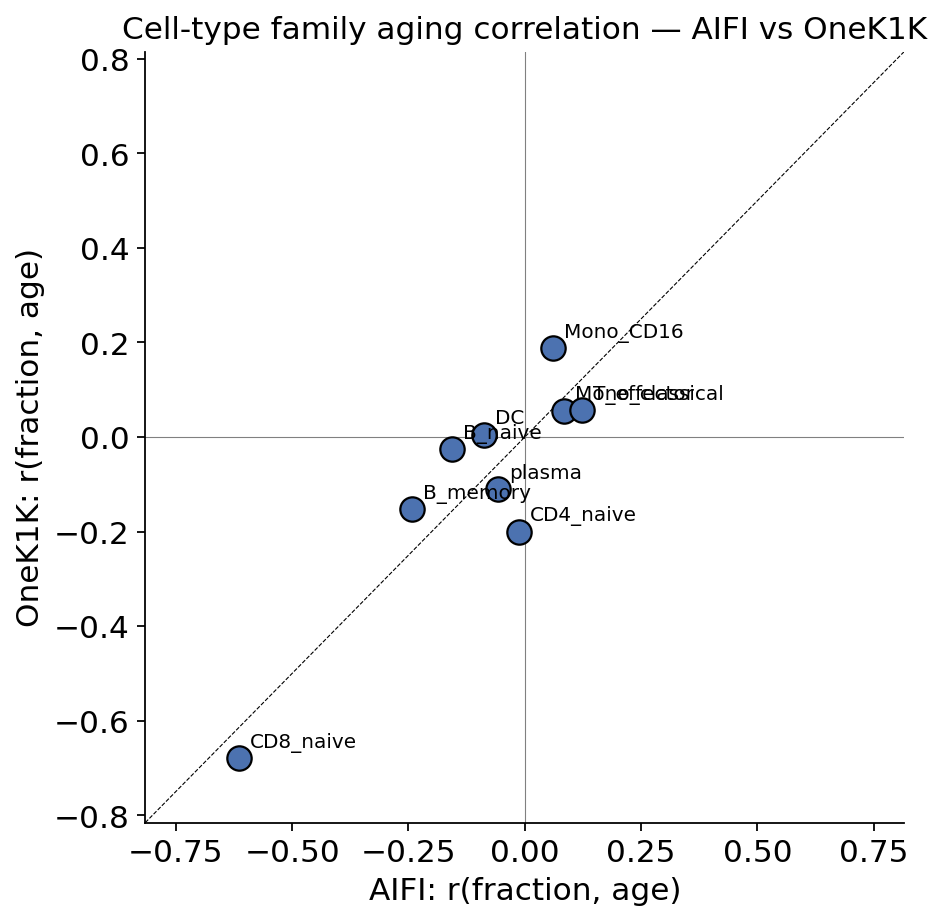

In [32]:
# Cross-cohort cell-type family agreement.
def family(name):
    lowered = str(name).lower()
    if "naive" in lowered and ("cd4" in lowered or "t4" in lowered): return "CD4_naive"
    if "naive" in lowered and ("cd8" in lowered or "t8" in lowered): return "CD8_naive"
    if "tem" in lowered or "effector" in lowered or "gzmb" in lowered: return "T_effector"
    if "treg" in lowered: return "Treg"
    if "naive b" in lowered or "b_naive" in lowered: return "B_naive"
    if "memory b" in lowered or "b mem" in lowered: return "B_memory"
    if "monocyte" in lowered and ("cd16" in lowered or "non-classical" in lowered): return "Mono_CD16"
    if "monocyte" in lowered: return "Mono_classical"
    if "nk" in lowered: return "NK"
    if "mait" in lowered or "gdt" in lowered: return "MAIT_gdT"
    if "dc" in lowered or "dendritic" in lowered: return "DC"
    if "plasma" in lowered: return "plasma"
    return None


aifi_family = corr_aging.assign(family=corr_aging.index.map(family)).dropna(subset=["family"]).groupby("family")["r"].mean()
onek1k_family = corr_onek1k.assign(family=corr_onek1k.index.map(family)).dropna(subset=["family"]).groupby("family")["r"].mean()
family_corr = pd.concat([aifi_family.rename("AIFI"), onek1k_family.rename("OneK1K")], axis=1).dropna()
print(family_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(family_corr["AIFI"], family_corr["OneK1K"], s=120, c="#4C72B0", edgecolor="black", zorder=3)
for family_name, row in family_corr.iterrows():
    ax.annotate(family_name, (row["AIFI"], row["OneK1K"]), xytext=(5, 5), textcoords="offset points", fontsize=9)
lim = max(family_corr.abs().max()) * 1.2
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("AIFI: r(fraction, age)"); ax.set_ylabel("OneK1K: r(fraction, age)")
ax.set_title("Cell-type family aging correlation — AIFI vs OneK1K")
despine(ax)
plt.tight_layout(); save_and_show("crosscohort_celltype_agreement")


## Generalisation: train on AIFI, predict on OneK1K

So far we re-trained each model from scratch on each cohort. Real
deployment looks more like *train once on a reference cohort, predict
on every new donor that comes in*. Two engineering choices and one
biological question.

**Engineering**

1. **Feature alignment.** AIFI and OneK1K have different gene panels and were
   PCA'd independently, so their `X_pca` spaces are incomparable out of the box.
   We match the cohorts on **shared gene symbols** (AIFI stores symbols in
   `var_names`; OneK1K stores Ensembl IDs with the symbol in
   `var["feature_name"]`) and build two shared-space inputs on each cohort:
   `obsm["X_shared_genes"]` (log-normalised expression on the shared panel, the
   gene-level input for PaSCient) and `obsm["X_pca_shared"]` (a PCA refit on AIFI
   shared genes and applied to both, the low-dim input for SampleCLR / MixMIL).
2. **Bag size.** AIFI donors have ~16K cells each, OneK1K donors have
   ~1.3K. We use a small bag of 200 cells/donor for both training and
   inference so OneK1K donors aren't dominated by zero-padding.

**Biological question.** Three protocols on the same models:

- **Zero-shot transfer** — train on AIFI, predict OneK1K with no
  further training. Worst case.
- **Fine-tuning with a small donor budget** — train on AIFI, then
  continue training on **10% of OneK1K donors** (with a smaller lr and
  fewer epochs), then predict the remaining 90%. Does a tiny budget
  of in-domain donors fix the transfer gap?
- AIFI in-sample for reference.

**Young-weighted FT subset.** AIFI only covers age 40-89, so the
AIFI-pretrained models are most likely to misjudge donors below 40
(OneK1K has a non-trivial under-40 cohort). A plain random 10% would
inherit OneK1K's natural age distribution and under-represent young
donors — exactly where the AIFI-trained models struggle. We instead
sample each donor with probability proportional to
``(max_age - age + 1)``, which mildly biases the FT subset toward
younger donors while still covering the full 19-97 range. The 90%
held-out test set never sees the fine-tune step. Below we report
predictions on **all donors** and separately on **donors with age >=
40**, the slice that matches AIFI's training range.


In [33]:
# --- Combined AIFI + OneK1K shared representation (build once, then cached) ---
# Both cohorts in one input space. Two shared layers, from the merged shared-gene
# object via scanpy: obsm['X_pca_shared'] (50-d scaled PCA; SampleCLR/MixMIL) and
# obsm['X_shared_genes'] (1595-d log-norm; PaSCient, gene-level). Cached as
# aifi_onek1k_combined.h5ad and loaded if present.
import scanpy as sc
import scipy.sparse as _sp

_DATA = Path("/ictstr01/groups/luckylab/workspace/vladimir.shitov/"
             "patpy-aging-tutorial/data/aging_benchmark/scvi_integration")
COMBINED_PATH = _DATA / "aifi_onek1k_combined.h5ad"
MERGED_GENES = _DATA / "merged_scvi_scanvi.h5ad"


def build_combined_shared_pca():
    merged = sc.read_h5ad(MERGED_GENES)
    merged.X = merged.layers["counts"].copy()
    merged.layers.clear()
    for key in list(merged.obsm):
        del merged.obsm[key]
    sc.pp.normalize_total(merged, target_sum=1e4)
    sc.pp.log1p(merged)
    lognorm = merged.X.copy()                 # gene-level (keep sparse)
    sc.pp.scale(merged, max_value=10)
    sc.pp.pca(merged, n_comps=50)
    out = sc.AnnData(obs=merged.obs[["dataset", "donor", "age"]].copy())
    out.obsm["X_pca_shared"] = np.asarray(merged.obsm["X_pca"], dtype=np.float32)
    out.obsm["X_shared_genes"] = _sp.csr_matrix(lognorm, dtype=np.float32)
    return out


if COMBINED_PATH.exists():
    combined = sc.read_h5ad(COMBINED_PATH)
    print(f"loaded combined object ({combined.n_obs:,} cells) from {COMBINED_PATH.name}")
else:
    print("building combined object (one-time, ~25 min)...")
    combined = build_combined_shared_pca()
    COMBINED_PATH.parent.mkdir(parents=True, exist_ok=True)
    combined.write(COMBINED_PATH)
    print(f"saved -> {COMBINED_PATH.name}")

combined.obs_names = combined.obs_names.astype(str)
_combined_index = pd.Index(combined.obs_names)
_pca_arr = np.asarray(combined.obsm["X_pca_shared"])
_genes_mat = combined.obsm["X_shared_genes"]


def attach_shared_features(adata, dataset):
    """Attach obsm['X_pca_shared'] (dense 50-d) and obsm['X_shared_genes'] (dense
    1595-d log-norm) from the combined object, matched per cell by '<dataset>-<barcode>'."""
    keys = pd.Index(dataset + "-" + adata.obs_names.astype(str))
    pos = _combined_index.get_indexer(keys)
    if (pos < 0).any():
        raise RuntimeError(f"{int((pos < 0).sum())}/{adata.n_obs} {dataset} cells absent from combined")
    adata.obsm["X_pca_shared"] = _pca_arr[pos].astype(np.float32)
    block = _genes_mat[pos]
    adata.obsm["X_shared_genes"] = np.asarray(block.todense() if _sp.issparse(block) else block, dtype=np.float32)


loaded combined object (5,007,494 cells) from aifi_onek1k_combined.h5ad


In [34]:
# Cross-cohort setup: attach the shared PCA to both cohorts, define the AIFI
# target folds. We pretrain on OneK1K (the larger cohort) and transfer to AIFI,
# so these numbers are directly comparable to the AIFI-only results above.
# (filter_small_samples with threshold 0 was a no-op; a plain copy is enough and
# attach_shared_features mutates obsm in place.)
aifi_t = adata.copy()
onek1k_t = adata_onek1k.copy()
attach_shared_features(aifi_t, "AIFI")
attach_shared_features(onek1k_t, "OneK1K")

aifi_donor_age = donor_meta["age"].astype(float)
onek1k_donor_age = donor_meta_onek1k["age"].astype(float)
print(f"OneK1K source: {onek1k_t.n_obs:,} cells ({onek1k_t.obs['donor'].nunique()} donors)")
print(f"AIFI target:   {aifi_t.n_obs:,} cells ({aifi_t.obs['donor'].nunique()} donors)")


def sample_young_weighted(donor_age, n_target, seed):
    """Draw `n_target` donors weighted by (max_age - age + 1) (keeps age spread)."""
    donor_age = donor_age.dropna().astype(float)
    if n_target >= len(donor_age):
        return list(donor_age.index)
    weights = (donor_age.max() - donor_age + 1.0).values
    weights = weights / weights.sum()
    rng = np.random.default_rng(seed)
    return list(rng.choice(donor_age.index.values, size=n_target, replace=False, p=weights))


# --- Kept demo: pretrain SampleCLR on OneK1K, fine-tune on 10% of AIFI donors,
#     predict the held-out AIFI donors. (Flipped from the old AIFI->OneK1K demo.) ---
FINETUNE_FRACTION = 0.10
aifi_donors_all = pd.Index(pd.unique(aifi_t.obs["donor"].astype(str)))
n_ft_demo = max(5, round(len(aifi_donor_age.dropna()) * FINETUNE_FRACTION))
aifi_train_demo, aifi_test_demo = donor_train_val_split(
    list(aifi_donors_all), aifi_donor_age, val_fraction=0.30, seed=SEED)
ft_demo_donors = sample_young_weighted(aifi_donor_age.reindex(aifi_train_demo), n_ft_demo, seed=SEED)
print(f"10% demo: fine-tune on {len(ft_demo_donors)} AIFI donors, test on {len(aifi_test_demo)} held-out AIFI donors")

OneK1K source: 1,248,980 cells (981 donors)
AIFI target:   3,758,514 cells (234 donors)


10% demo: fine-tune on 23 AIFI donors, test on 71 held-out AIFI donors


**Reading the panels.** The left column is zero-shot transfer (no
OneK1K data ever seen); the right column is the same model after 15
fine-tune epochs on 10% of OneK1K donors at a 10× smaller learning
rate. A big jump from left to right means the AIFI-pretrained model
*has* useful aging features but they live in a slightly different
geometry — a small donor budget is enough to recalibrate. A small
jump means the supervised features are AIFI-specific and only a
re-train from scratch on OneK1K would help.

**Interpreting the transfer.** A perfect transfer would mean the model
learnt aging biology rather than AIFI-specific artefacts (batch
structure, recruitment bias, the 40-89 age range). Two failure modes
to watch for:

- **Floor effect at the AIFI age range.** OneK1K donors aged 19-39 may
  all collapse onto AIFI's youngest decade (40s), giving them an
  upward-biased predicted age. The scatter above makes this visible.
- **Sequencing-platform / annotation differences.** The shared-gene
  PCA only covers what both cohorts measured; cohort-specific gene
  programs are lost.

The MAE and Spearman on the right-hand scatter are the headline:
how many years off, and how well-ranked, are the predictions on a
cohort the model has never seen.

## Inside SampleCLR — what does fine-tuning move?

We snapshotted the aggregator twice during the SampleCLR run above —
once after self-supervised pretrain (SSL) and once after fine-tuning on
age (FT). Now we extract the per-cell, per-head attention weights from
both and ask three questions:

1. How does the held-out age score change SSL → FT?
2. Which immune cell types do the attention heads focus on, and how
   does that shift with FT?
3. Which (cell type, head) combinations correlate with donor age, and
   what genes drive that head's attention inside those cells?

In [35]:
def attention_weights_for_donors(aggregator, adata, donor_order, n_cells_per_donor=TRAIN_BAG_SIZE):
    """Per-cell, per-head SampleCLR attention as a tidy DataFrame.

    One row per (donor, sampled cell) with the cell type, the original ``obs``
    row index, and one ``head_<h>`` column per attention head.
    """
    aggregator.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    rng = np.random.default_rng(SEED)
    celltype_key = "AIFI_L2" if "AIFI_L2" in adata.obs else "cell_type"
    donor_of_cell = adata.obs["donor"].astype(str).values
    celltype_of_cell = adata.obs[celltype_key].astype(str).values
    cell_features = adata.obsm["X_pca"]

    rows = []
    with torch.no_grad():
        for donor in donor_order:
            cell_indices = np.flatnonzero(donor_of_cell == donor)
            if len(cell_indices) == 0:
                continue
            replace = len(cell_indices) < n_cells_per_donor
            picked = np.sort(rng.choice(cell_indices, size=n_cells_per_donor, replace=replace))
            features = torch.tensor(cell_features[picked].astype(np.float32)).unsqueeze(0).to(device)
            _, weights = aggregator(features, return_weights=True)
            weights = weights.squeeze(0).cpu().numpy()  # (n_cells, n_heads)
            for position, cell_index in enumerate(picked):
                row = {"donor": donor, "obs_idx": int(cell_index), "cell_type": celltype_of_cell[cell_index]}
                row.update({f"head_{head}": float(weights[position, head]) for head in range(weights.shape[1])})
                rows.append(row)
    return pd.DataFrame(rows)


# FT attention from the fine-tuned aggregator captured during the main run.
att_ft = attention_weights_for_donors(
    sclr_model.aggregator, adata, list(pd.unique(adata.obs["donor"].astype(str)))
)
n_heads = sum(col.startswith("head_") for col in att_ft.columns)
print(f"FT attention: {len(att_ft):,} rows across {att_ft['cell_type'].nunique()} cell types and {n_heads} heads")


FT attention: 234,000 rows across 28 cell types and 2 heads


We already have the SSL aggregator: `fit_sampleclr` snapshotted it right after the
self-supervised stage (`sclr_ssl_aggregator`). We reuse that snapshot here instead
of training a second model, and compare it against the **same** model after age
fine-tuning (`sclr_model.aggregator`) to see what fine-tuning moves.

In [36]:
# Reuse the SSL aggregator captured during the main SampleCLR run (no second model
# is trained). Both SSL and FT attention are computed on the same donors and cells.
all_donors = list(pd.unique(adata.obs["donor"].astype(str)))
att_ssl = attention_weights_for_donors(sclr_ssl_aggregator, adata, all_donors)
print(f"SSL attention: {len(att_ssl):,} rows")

SSL attention: 234,000 rows


### 1. SSL vs FT held-out age scores

### 2. Attention distribution across cell types (SSL vs FT)

Mean attention per (cell type × head) — first 5 rows of FT:
                    head_0  head_1
cell_type                         
ASDC                   0.0     0.0
CD14 monocyte          0.0     0.0
CD16 monocyte          0.0     0.0
CD56bright NK cell     0.0     0.0
CD56dim NK cell        0.0     0.0


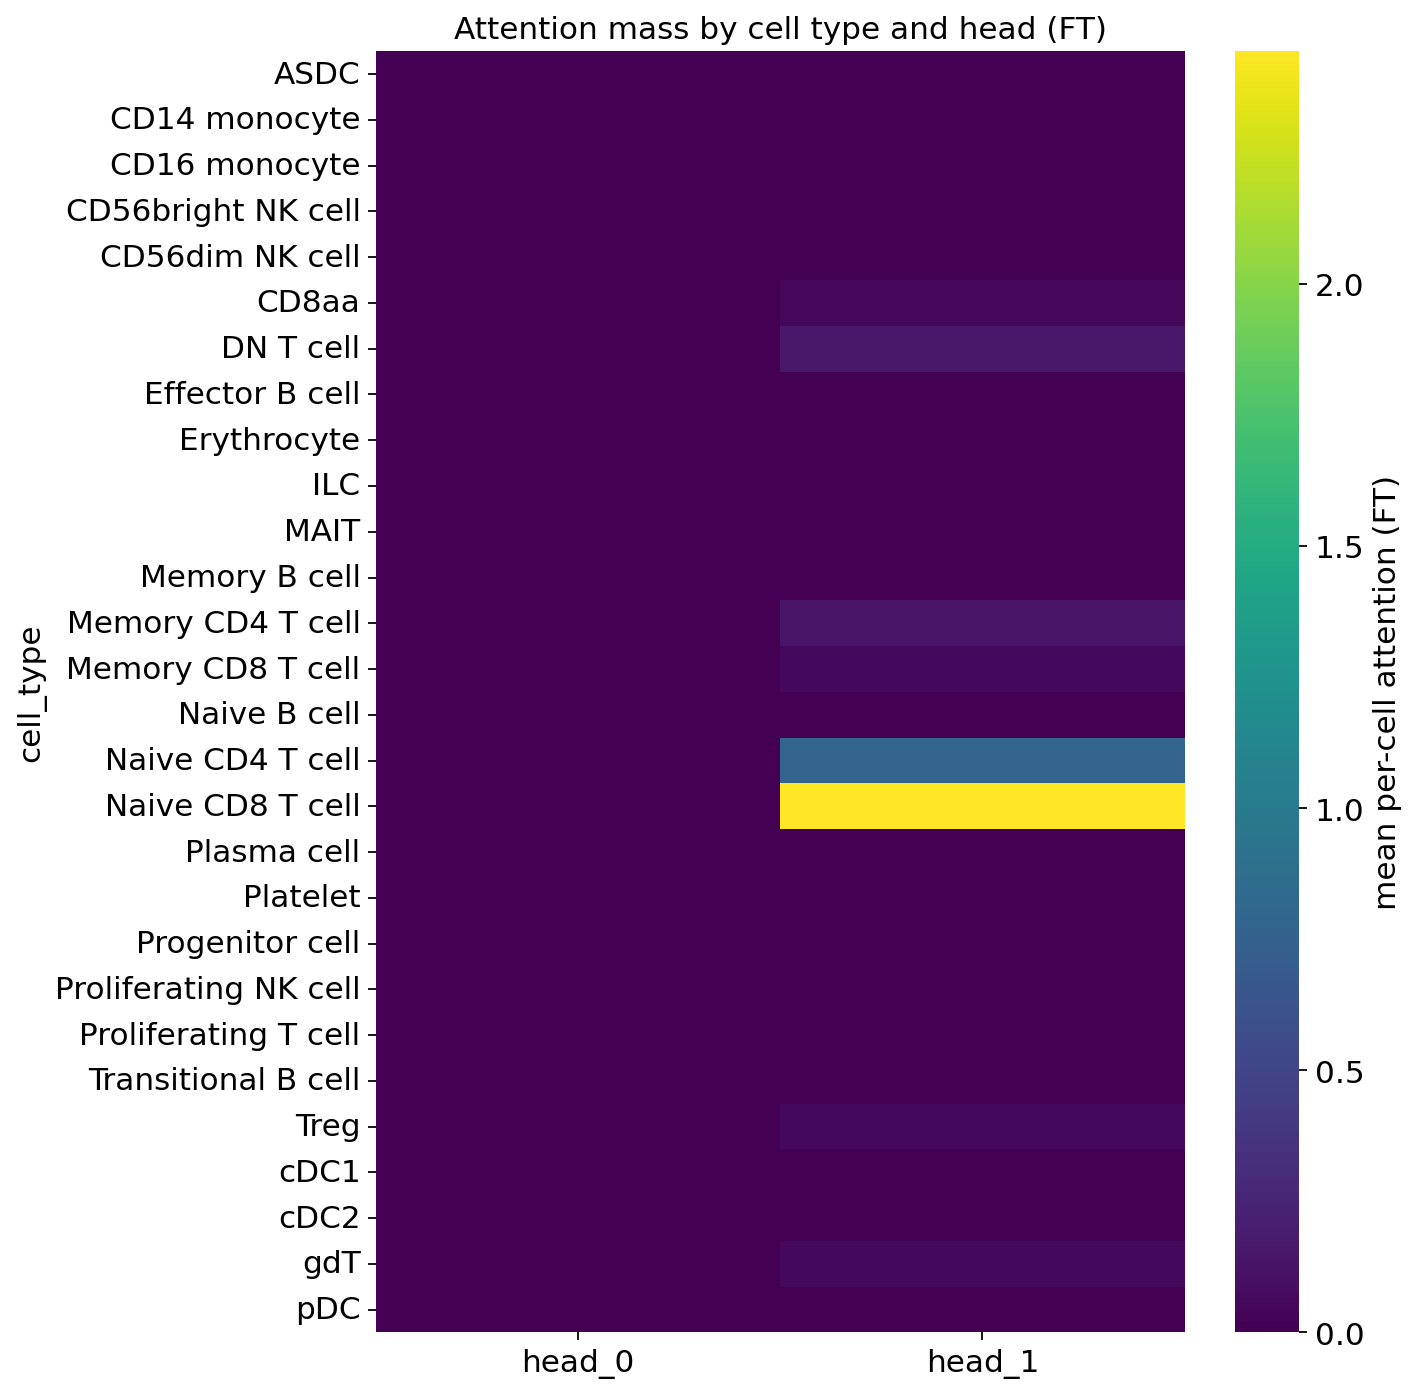

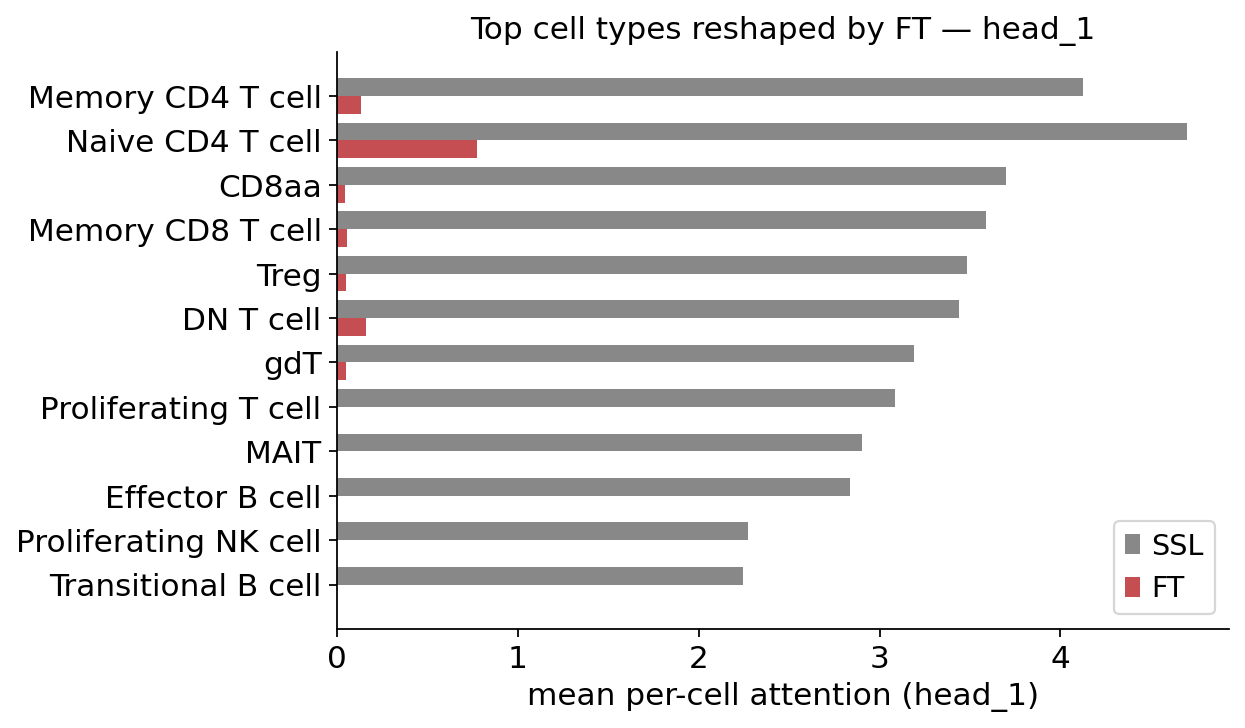

In [37]:
def attention_by_celltype(att):
    head_cols = [c for c in att.columns if c.startswith("head_")]
    return att.groupby("cell_type", observed=True)[head_cols].mean()


attention_ssl = attention_by_celltype(att_ssl)
attention_ft = attention_by_celltype(att_ft)
print("Mean attention per (cell type × head) — first 5 rows of FT:")
print(attention_ft.head().round(3).to_string())

# Heatmap of FT attention per (cell type × head).
fig, ax = plt.subplots(figsize=(9, max(5, 0.32 * len(attention_ft))))
sns.heatmap(attention_ft, ax=ax, cmap="viridis", cbar_kws={"label": "mean per-cell attention (FT)"})
ax.grid(False)
ax.set_title("Attention mass by cell type and head (FT)")
plt.tight_layout(); save_and_show("attention_heatmap_ft")

max_weight_idx = np.argmax(attention_ft.max(axis=0))
head_name = attention_ft.columns[max_weight_idx]
head0_comparison = pd.concat(
    [attention_ssl[head_name].rename("SSL"), attention_ft[head_name].rename("FT")], axis=1
).dropna()
head0_comparison = (
    head0_comparison.assign(delta=(head0_comparison["FT"] - head0_comparison["SSL"]).abs())
    .sort_values("delta", ascending=False)
    .head(12)
)
positions = np.arange(len(head0_comparison))
fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(head0_comparison))))
ax.barh(positions - 0.2, head0_comparison["SSL"], height=0.4, color="#888", label="SSL")
ax.barh(positions + 0.2, head0_comparison["FT"], height=0.4, color="#C44E52", label="FT")
ax.set_yticks(positions); ax.set_yticklabels(head0_comparison.index)
ax.set_xlabel(f"mean per-cell attention ({head_name})")
ax.invert_yaxis(); ax.legend()
ax.set_title(f"Top cell types reshaped by FT — {head_name}")
despine(ax)
plt.tight_layout(); save_and_show("attention_head0_reshape")


In [38]:
attention_ft[head_name]

cell_type
ASDC                     0.000000
CD14 monocyte            0.000000
CD16 monocyte            0.000000
CD56bright NK cell       0.000000
CD56dim NK cell          0.000000
CD8aa                    0.043402
DN T cell                0.161722
Effector B cell          0.000000
Erythrocyte              0.000000
ILC                      0.000000
MAIT                     0.000755
Memory B cell            0.000000
Memory CD4 T cell        0.132842
Memory CD8 T cell        0.053619
Naive B cell             0.000000
Naive CD4 T cell         0.775287
Naive CD8 T cell         2.443000
Plasma cell              0.000000
Platelet                 0.000000
Progenitor cell          0.000000
Proliferating NK cell    0.001474
Proliferating T cell     0.000000
Transitional B cell      0.000000
Treg                     0.051158
cDC1                     0.000000
cDC2                     0.000000
gdT                      0.049504
pDC                      0.000000
Name: head_1, dtype: float64

In [39]:
# FT attention each cell type receives (NaN for cell types not sampled this run).
corr_aging[f"{head_name}_attention_weights"] = attention_ft[head_name].reindex(corr_aging.index)
corr_aging

,r,p,head_1_attention_weights
Naive CD8 T cell,-0.615222,9.247657e-26,2.443000
CD8aa,-0.415130,3.658361e-11,0.043402
MAIT,-0.343620,6.915596e-08,0.000755
ILC,-0.250032,1.107011e-04,0.000000
Memory B cell,-0.242111,1.843553e-04,0.000000
CD56bright NK cell,-0.172359,8.235255e-03,0.000000
gdT,-0.165061,1.144535e-02,0.049504
Naive B cell,-0.156266,1.674213e-02,0.000000
cDC2,-0.114089,8.158278e-02,0.000000
DN T cell,-0.107387,1.012861e-01,0.161722


In [40]:
corr_aging["r_magnitude"] = corr_aging["r"].abs()

In [41]:
# Does FT attend to the cell types whose composition tracks age most strongly?
attention_vs_aging = corr_aging[["r_magnitude", f"{head_name}_attention_weights"]].dropna()
pearsonr(attention_vs_aging["r_magnitude"], attention_vs_aging[f"{head_name}_attention_weights"])

PearsonRResult(statistic=np.float64(0.6138523495120186), pvalue=np.float64(0.0005121657616277))

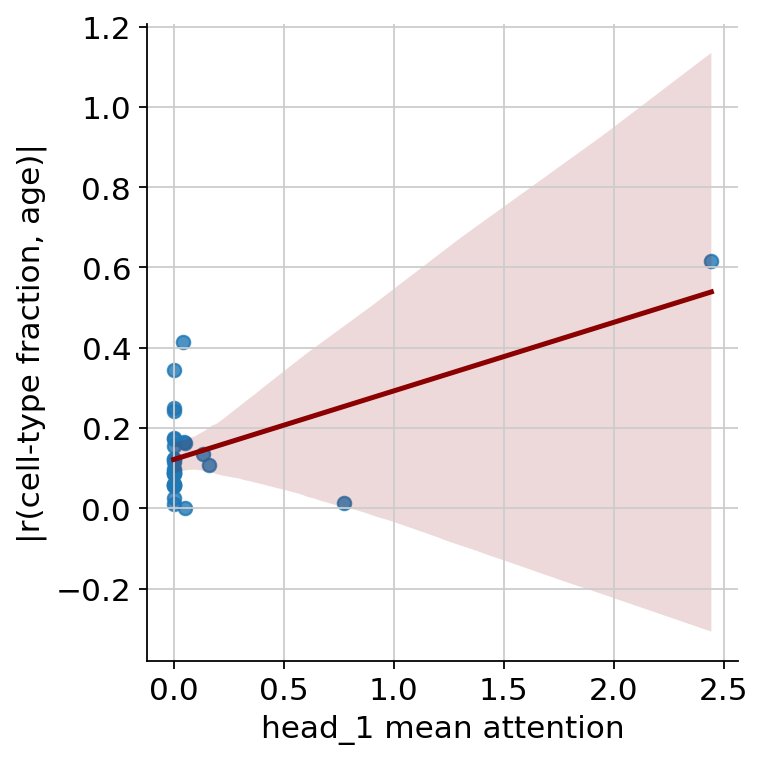

In [42]:
# Attention a head puts on each cell type vs that cell type's aging signal — saved to file.
g = sns.lmplot(corr_aging, x=f"{head_name}_attention_weights", y="r_magnitude", line_kws={"color": "darkred"})
g.set_axis_labels(f"{head_name} mean attention", "|r(cell-type fraction, age)|")
save_and_show("attention_vs_age_correlation", g.figure)

### Attention dotplot (SampleCLR heads × cell type)

A complementary view of the same FT attention matrix: a scanpy dotplot
where colour encodes mean attention weight and size encodes the fraction
of cells with non-zero attention. Easier to read off than the dense
heatmap when there are many cell types.


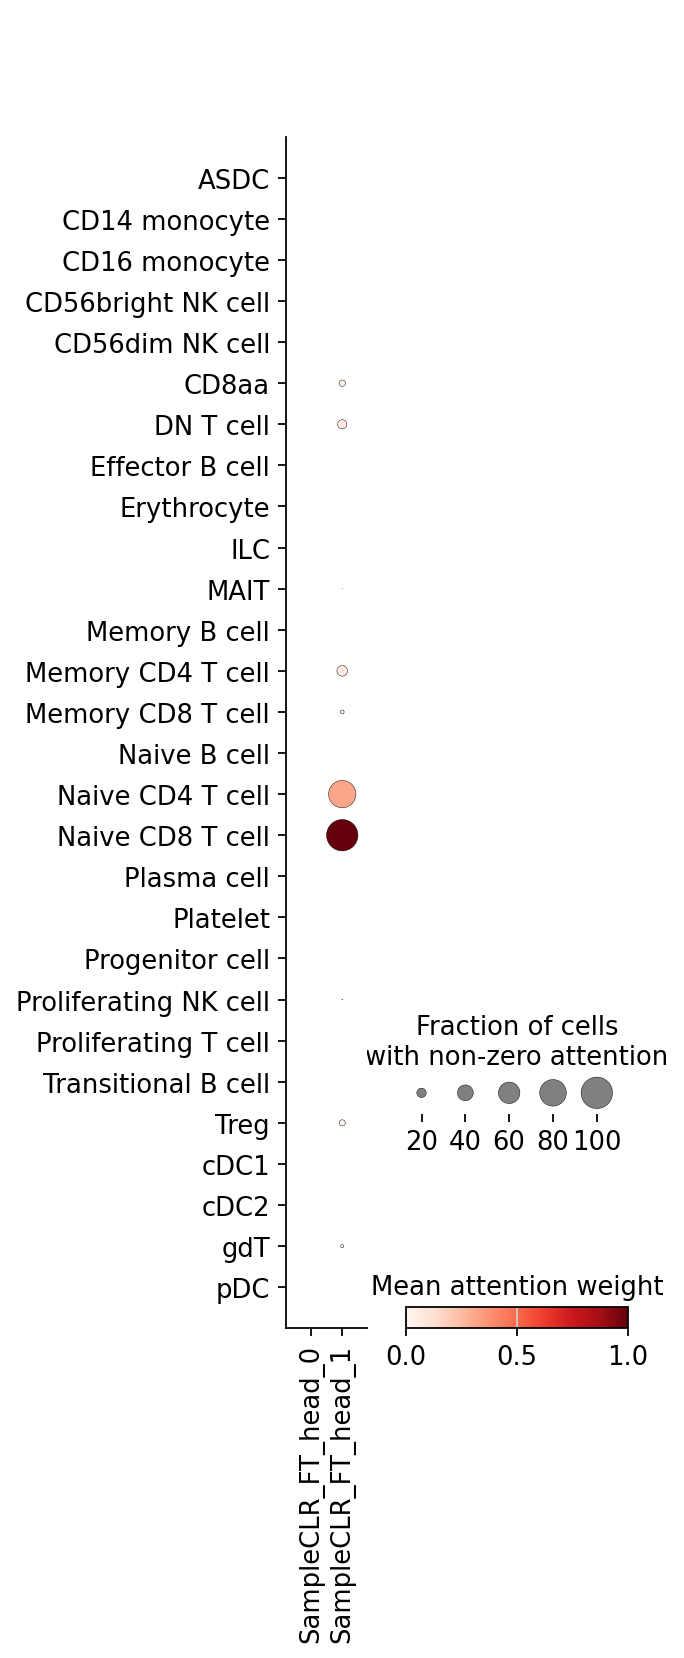

In [43]:
# Attention -> AnnData with one obs per (sampled) cell and one var per head.
head_cols = [c for c in att_ft.columns if c.startswith("head_")]
head_names = [f"SampleCLR_FT_head_{c.split('_')[1]}" for c in head_cols]
att_X = att_ft[head_cols].values.astype(np.float32)
att_adata = ad.AnnData(X=att_X)
att_adata.obs["cell_type"] = pd.Categorical(att_ft["cell_type"].astype(str).values)
att_adata.var_names = head_names

sc.pl.dotplot(att_adata, var_names=list(att_adata.var_names),
              groupby="cell_type",
              colorbar_title="Mean attention weight",
              size_title="Fraction of cells\nwith non-zero attention",
              standard_scale="var")


### Persist SampleCLR cell-level attention weights

`att_ssl` and `att_ft` are the per-cell, per-head attention weights at the
self-supervised and fine-tuned stages — one row per (donor, sampled
cell), plus `cell_type` and `obs_idx` (the row index into the original
AIFI ``adata``). We dump both DataFrames to parquet so the
gene-attention analysis below can be re-run without retraining
SampleCLR twice (the SSL re-train in cell 51 alone takes a few
minutes).


In [44]:
ATT_DIR = META_ADATA_DIR
ATT_SSL_PATH = ATT_DIR / "sampleclr_attention_ssl.parquet"
ATT_FT_PATH  = ATT_DIR / "sampleclr_attention_ft.parquet"
try:
    att_ssl.to_parquet(ATT_SSL_PATH, index=False)
    att_ft.to_parquet(ATT_FT_PATH, index=False)
    print(f"attention SSL -> {ATT_SSL_PATH}  ({ATT_SSL_PATH.stat().st_size / 1e6:.1f} MB, "
          f"{len(att_ssl):,} rows)")
    print(f"attention FT  -> {ATT_FT_PATH}  ({ATT_FT_PATH.stat().st_size / 1e6:.1f} MB, "
          f"{len(att_ft):,} rows)")
except Exception as e:
    # pyarrow may be missing; fall back to CSV (~10x bigger but always works).
    print(f"parquet write failed ({e}); falling back to CSV")
    att_ssl.to_csv(ATT_DIR / "sampleclr_attention_ssl.csv", index=False)
    att_ft.to_csv(ATT_DIR / "sampleclr_attention_ft.csv", index=False)
    print(f"attention SSL -> {ATT_DIR / 'sampleclr_attention_ssl.csv'}")
    print(f"attention FT  -> {ATT_DIR / 'sampleclr_attention_ft.csv'}")


attention SSL -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts/sampleclr_attention_ssl.parquet  (3.0 MB, 234,000 rows)
attention FT  -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/notebook_artifacts/sampleclr_attention_ft.parquet  (1.9 MB, 234,000 rows)


### 3. (cell type, head) correlation with age

Top (cell_type, head) age correlations after FT:
        cell_type   head         r  nonzero_fraction  n_cells  n_donors
Memory CD4 T cell head_1  0.378716          0.234657    44107       234
 Naive CD4 T cell head_1  0.214594          0.830769    46280       234
 Naive CD8 T cell head_1 -0.206177          0.997284    10310       228
            CD8aa head_1  0.128354          0.119718      142        72
             Treg head_1 -0.103929          0.113854     8265       234
        DN T cell head_1 -0.026198          0.195965      694       211


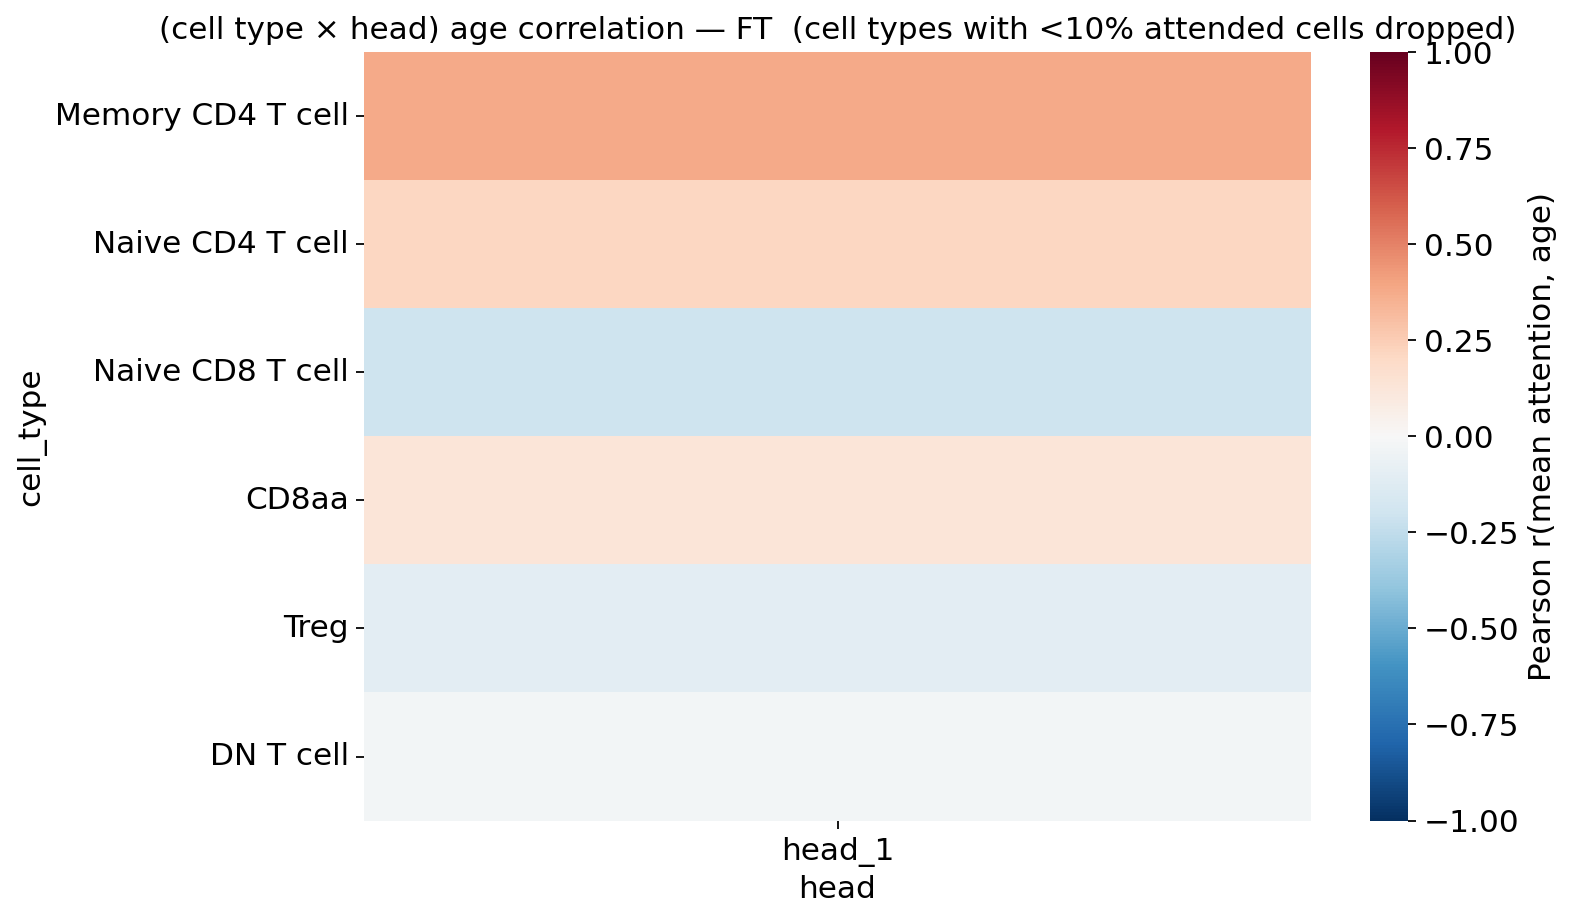

In [45]:
def celltype_head_age_corr(att, meta, min_nonzero_fraction=0.10):
    """Per (cell type, head): Pearson r between donor-mean attention and age.

    A head that attends to almost no cells of a given type carries no reliable
    signal there, so (cell type, head) pairs where fewer than
    ``min_nonzero_fraction`` of that cell type's cells receive non-zero attention
    are dropped.
    """
    head_cols = [c for c in att.columns if c.startswith("head_")]
    rows = []
    for cell_type, group in att.groupby("cell_type", observed=True):
        nonzero_fraction = (group[head_cols] > 0).mean()
        per_donor = (
            group.groupby("donor", observed=True)[head_cols].mean()
            .join(meta["age"]).dropna(subset=["age"])
        )
        if len(per_donor) < 5:
            continue
        age = per_donor.pop("age").values.astype(float)
        for head in head_cols:
            if nonzero_fraction[head] < min_nonzero_fraction:
                continue
            attention = per_donor[head].values.astype(float)
            r = float(np.corrcoef(age, attention)[0, 1]) if np.std(attention) > 1e-8 else np.nan
            rows.append({
                "cell_type": cell_type, "head": head, "r": r,
                "nonzero_fraction": float(nonzero_fraction[head]),
                "n_cells": int(len(group)), "n_donors": int(len(per_donor)),
            })
    return pd.DataFrame(rows, columns=["cell_type", "head", "r", "nonzero_fraction", "n_cells", "n_donors"])


def _sorted_corr(att):
    df = celltype_head_age_corr(att, donor_meta)
    if "r" in df.columns and not df.empty:
        return df.sort_values("r", key=lambda s: s.abs(), ascending=False)
    return df

corr_ft = _sorted_corr(att_ft)
corr_ssl = _sorted_corr(att_ssl)
if corr_ft.empty or "r" not in corr_ft.columns:
    # No (cell type, head) survived the >=10%-attended filter this run (sparse
    # attention varies by GPU/seed); skip the heatmap rather than abort the render.
    print("No (cell type, head) survived the attention/age-correlation filters this run; "
          "skipping the FT attention-correlation heatmap.")
else:
    print("Top (cell_type, head) age correlations after FT:")
    print(corr_ft.head(12).to_string(index=False))

    # Heatmap of the most age-correlated cell types. Only cell types that receive
    # attention from >=10% of their cells survive the filter above, so the rows are
    # all reliable. The figure is sized generously so the cell-type labels are legible.
    matrix = corr_ft.pivot_table(index="cell_type", columns="head", values="r")
    matrix = matrix.reindex(matrix.abs().max(axis=1).sort_values(ascending=False).head(20).index)
    fig, ax = plt.subplots(figsize=(10, max(6, 0.45 * len(matrix))))
    sns.heatmap(matrix, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                cbar_kws={"label": "Pearson r(mean attention, age)"})
    ax.grid(False)
    ax.set_title("(cell type × head) age correlation — FT  (cell types with <10% attended cells dropped)")
    plt.tight_layout(); save_and_show("celltype_head_age_corr")


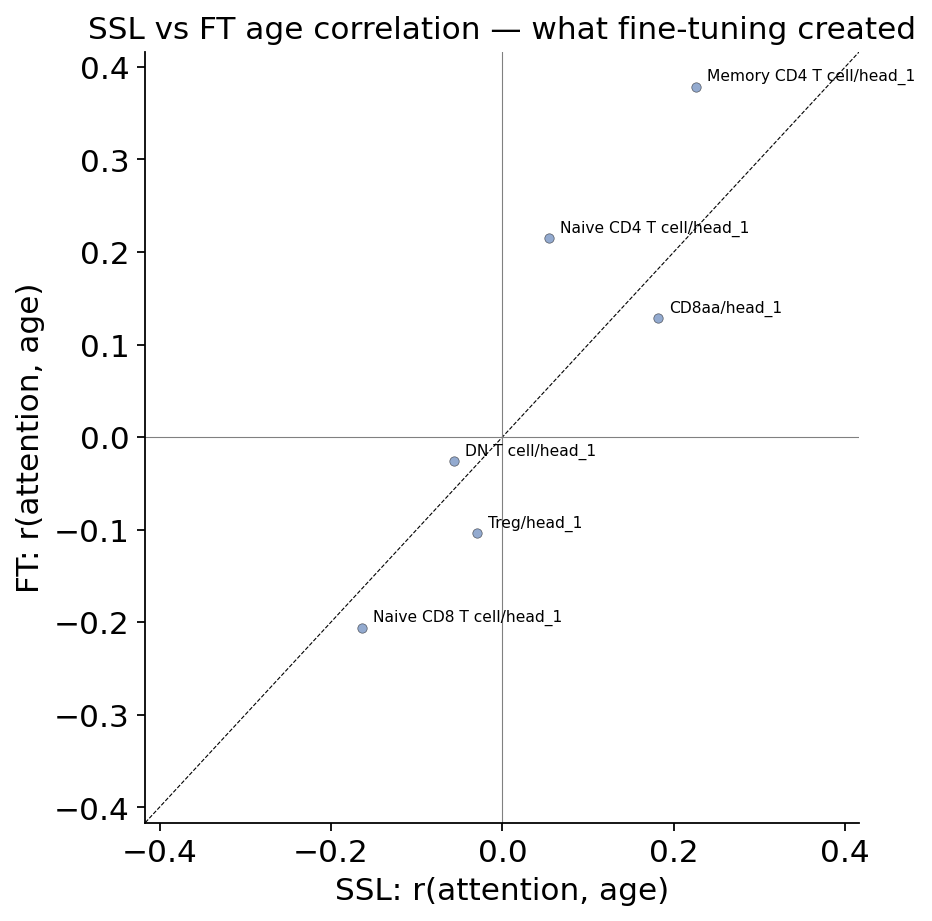

In [46]:
# SSL vs FT scatter — points far from the diagonal are what fine-tuning created.
ssl_vs_ft = (
    corr_ft[["cell_type", "head", "r"]].rename(columns={"r": "FT"})
    .merge(corr_ssl[["cell_type", "head", "r"]].rename(columns={"r": "SSL"}), on=["cell_type", "head"], how="inner")
    .dropna(subset=["SSL", "FT"])
)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ssl_vs_ft["SSL"], ssl_vs_ft["FT"], s=18, color="#4C72B0", alpha=0.6, edgecolor="black", lw=0.3)
biggest_shifts = ssl_vs_ft.assign(delta=(ssl_vs_ft["FT"] - ssl_vs_ft["SSL"]).abs()).sort_values("delta", ascending=False).head(8)
for _, row in biggest_shifts.iterrows():
    ax.annotate(f"{str(row['cell_type'])[:20]}/{row['head']}", (row["SSL"], row["FT"]),
                xytext=(5, 3), textcoords="offset points", fontsize=7)
abs_max = float(ssl_vs_ft[["SSL", "FT"]].abs().to_numpy().max()) if not ssl_vs_ft.empty else 0.1
lim = max(abs_max if np.isfinite(abs_max) else 0.1, 0.1) * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("SSL: r(attention, age)"); ax.set_ylabel("FT: r(attention, age)")
ax.set_title("SSL vs FT age correlation — what fine-tuning created")
despine(ax)
plt.tight_layout(); save_and_show("ssl_vs_ft_corr_scatter")


### 4. Genes that drive the age-correlated attention

In [47]:
def gene_attention_correlation(att, adata, hits, n_top_genes=10):
    """For each (cell type, head) hit, the genes whose expression best correlates
    with that head's per-cell attention within the cell type."""
    gene_names = np.asarray(adata.var_names)
    rows = []
    for _, hit in hits.iterrows():
        subset = att[att["cell_type"] == hit["cell_type"]]
        if len(subset) < 30:
            continue
        obs_idx = subset["obs_idx"].astype(int).values
        attention = subset[hit["head"]].values.astype(np.float32)
        expression = adata.X[obs_idx]
        if hasattr(expression, "toarray"):
            expression = expression.toarray()
        expression = np.asarray(expression, dtype=np.float32)
        attention_z = (attention - attention.mean()) / (attention.std() + 1e-12)
        expression_z = (expression - expression.mean(axis=0)) / (expression.std(axis=0) + 1e-12)
        correlations = (attention_z @ expression_z) / len(attention)
        top = np.argsort(-np.abs(correlations))[:n_top_genes]
        for gene_pos in top:
            rows.append({"cell_type": hit["cell_type"], "head": hit["head"],
                         "head_age_r": float(hit["r"]), "gene": gene_names[gene_pos],
                         "r": float(correlations[gene_pos]), "n_cells": int(len(attention))})
    return pd.DataFrame(rows, columns=["cell_type", "head", "head_age_r", "gene", "r", "n_cells"])


top_hits = corr_ft.head(6).copy()
gene_attention_corr = gene_attention_correlation(att_ft, adata, top_hits, n_top_genes=12)
print(gene_attention_corr.head(15).round(3).to_string(index=False))


        cell_type   head  head_age_r   gene      r  n_cells
Memory CD4 T cell head_1       0.379  DACT1  0.295    44107
Memory CD4 T cell head_1       0.379   BCL2  0.287    44107
Memory CD4 T cell head_1       0.379 PCED1B  0.277    44107
Memory CD4 T cell head_1       0.379 RNF157  0.268    44107
Memory CD4 T cell head_1       0.379   CCR7  0.262    44107
Memory CD4 T cell head_1       0.379  IGF1R  0.259    44107
Memory CD4 T cell head_1       0.379   LEF1  0.255    44107
Memory CD4 T cell head_1       0.379  SESN3  0.255    44107
Memory CD4 T cell head_1       0.379 FAM13A  0.253    44107
Memory CD4 T cell head_1       0.379    EDA  0.253    44107
Memory CD4 T cell head_1       0.379  SATB1  0.249    44107
Memory CD4 T cell head_1       0.379  MYO1F -0.248    44107
 Naive CD4 T cell head_1       0.215   CISH  0.399    46280
 Naive CD4 T cell head_1       0.215 PCED1B  0.381    46280
 Naive CD4 T cell head_1       0.215   PIM1  0.373    46280


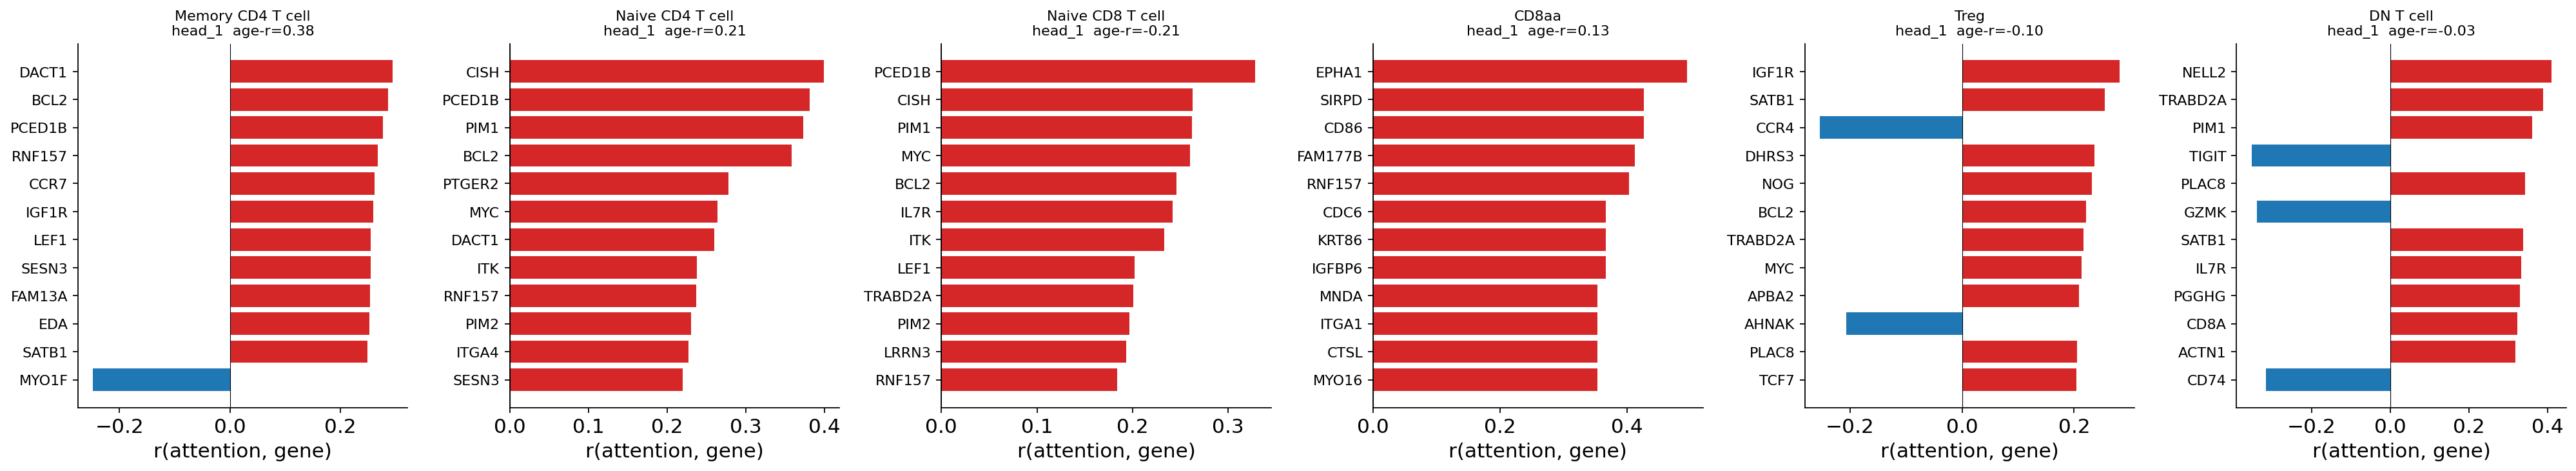

In [48]:
# Gene-attention panels, one per (cell type, head) hit, laid out in a single row.
n_hits = top_hits.shape[0]
if n_hits == 0:
    print("No (cell type, head) hits survived the filters this run; skipping gene-attention panels.")
else:
    fig, axes = plt.subplots(1, n_hits, figsize=(n_hits * 4.2, 4.8), squeeze=False)
    for ax, (_, hit) in zip(axes.ravel(), top_hits.iterrows()):
        genes = gene_attention_corr[
            (gene_attention_corr["cell_type"] == hit["cell_type"]) & (gene_attention_corr["head"] == hit["head"])
        ].sort_values("r", key=lambda s: s.abs(), ascending=False)
        if genes.empty:
            ax.set_visible(False)
            continue
        ax.barh(genes["gene"], genes["r"],
                color=["#1f77b4" if value < 0 else "#d62728" for value in genes["r"]])
        ax.axvline(0, color="k", lw=0.5)
        ax.set_title(f"{str(hit['cell_type'])[:30]}\n{hit['head']}  age-r={hit['r']:.2f}", fontsize=10)
        ax.set_xlabel("r(attention, gene)")
        ax.tick_params(axis="y", labelsize=10)
        ax.invert_yaxis()
        despine(ax)
    plt.tight_layout(); save_and_show("gene_attention_panels")

**Reading the panels.** Red bars: cells with **higher** expression of
that gene receive **more** attention. Blue bars: cells with **lower**
expression of that gene receive **more** attention. The header line
gives the cell type, the head index, and the age correlation of that
head's per-donor mean attention.

For example, an NK-cell head whose age correlation is positive and
whose red bars include `GZMB`, `PRF1`, `NKG7` is the model saying *as
donors age, I find more cytotoxic-program NK cells, and I weight them
up*. The same pattern shows up in CD8 T-cell heads with terminal
effector markers and CD14+ monocyte heads with activation markers.

## Sweeping the fine-tune donor budget

10% was an arbitrary choice. How does test-set age prediction change
as we vary the fraction `f` of OneK1K donors used for fine-tuning?

We sweep `f ∈ {0, 0.05, 0.10, 0.20, 0.30, 0.50}` with 5-fold
age-stratified CV over OneK1K donors. For each fold we hold out 20%
of donors as the test set, then for each fraction sample `f × N_total`
donors from the remaining 80% (young-weighted, same scheme as the 10%
subset above), restore each method to its AIFI-pretrained weights, run
the FT stage, and predict the test fold's ages. We report `R²`,
Spearman ρ, and MAE.

The sweep re-uses the AIFI-pretrained state snapshots we captured
earlier (``pa_aifi_state`` for PaSCient, ``sclr_aifi_state`` for
SampleCLR). MixMIL gets its own AIFI pretrain inside this section.

This cell takes a while on a GPU (~80 minutes for the full sweep);
results are saved incrementally to a CSV so the plotting cell can
re-read partial progress if needed.


In [49]:
from sklearn.model_selection import StratifiedKFold

SWEEP_DIR = DATA_ROOT / f"onek1k_to_aifi_sweep{SMOKE_SUFFIX}"
SWEEP_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_CSV = SWEEP_DIR / "scores.csv"

FRACTIONS = np.arange(0.0, 1.01, 0.1)
N_FOLDS = 2 if SMOKE else 5
SAMPLECLR_FT_EPOCHS = 5 if SMOKE else 20
PASCIENT_SRC_EPOCHS = 2 if SMOKE else 30
PASCIENT_FT_EPOCHS = 2 if SMOKE else 15
PASCIENT_FT_LR = 1e-5
device = "cuda" if torch.cuda.is_available() else "cpu"
sclr_arch = {key: value for key, value in SCLR_ARCH.items() if key != "output_dim"}  # output_dim is an explicit SampleCLR arg


def age_stratified_kfold(donor_age, n_splits=N_FOLDS, seed=SEED):
    donor_age = donor_age.dropna().astype(float)
    bins = pd.qcut(donor_age, q=min(5, n_splits), duplicates="drop").cat.codes.values
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    donors = donor_age.index.tolist()
    return [([donors[i] for i in tr], [donors[i] for i in te]) for tr, te in splitter.split(donors, bins)]


# ---- 1) SampleCLR OneK1K source (shared-PCA layer), via patpy.tl.SampleCLR ----
sampleclr_source_epochs = 10 if SMOKE else 30
onek1k_donors = list(pd.unique(onek1k_t.obs["donor"].astype(str)))
source_train, source_val = donor_train_val_split(onek1k_donors, onek1k_donor_age, val_fraction=SCLR_VAL_INNER, seed=SEED)
sclr_src = patpy.tl.SampleCLR(
    sample_key="donor",
    label_keys=["age"],
    tasks=["regression"],
    layer="X_pca_shared",
    output_dim=SCLR_ARCH["output_dim"],
    n_cells_per_sample=resolve_cells_per_sample(onek1k_t),
    num_epochs_pretrain=SCLR_SSL_EPOCHS,
    num_epochs_fine_tune=sampleclr_source_epochs,
    batch_size=SCLR_BATCH_SIZE,
    device=device,
    seed=SEED,
    lambda_=SCLR_LAMBDA,
    contrastive_loss_temperature=SCLR_SSL_TEMP,
    aggregator_activation="relu",
    attention_sparsity_lambda=SCLR_ATTN_SPARSITY,
    use_batch_aware_sampler=False,
    early_stopping_patience=25,
    train_ids=list(source_train),
    val_ids=list(source_val),
    **sclr_arch,
)
t0 = time.time()
sclr_src.prepare_anndata(onek1k_t, pretrain=True, fine_tune=False, pretrain_val_metric="loss",
                         pretrain_num_warmup_epochs=max(1, SCLR_SSL_EPOCHS // 5), verbose=False)
set_sclr_ft_temperature(sclr_src._sclr_model)
set_finetune_lr(sclr_src._sclr_model)
sclr_src.fine_tune("age", "regression", num_epochs=sampleclr_source_epochs,
                   num_warmup_epochs=max(1, sampleclr_source_epochs // 5), val_metric="loss", verbose=False)
sclr_src_model = sclr_src._sclr_model   # underlying ContrastiveModel (weight snapshot below)
sclr_src_state = {
    "projector": {k: v.detach().cpu().clone() for k, v in sclr_src_model.projector.state_dict().items()},
    "aggregator": {k: v.detach().cpu().clone() for k, v in sclr_src_model.aggregator.state_dict().items()},
}
print(f"SampleCLR OneK1K source: {time.time() - t0:.0f}s")


# ---- 2) PaSCient OneK1K source (gene-level shared layer) ----
pascient_src = patpy.tl.PaSCient(
    sample_key="donor",
    label_keys=["age"],
    tasks=["regression"],
    cell_group_key=None,
    layer="X_shared_genes",
    n_cells=TRAIN_BAG_SIZE,
    batch_size=32,
    n_epochs=PASCIENT_SRC_EPOCHS,
    device=device,
    normalize=False,
    seed=SEED,
)
pascient_src.prepare_anndata(onek1k_t, train=True)
pascient_src_state = {k: v.detach().cpu().clone() for k, v in pascient_src._pascient_model.state_dict().items()}
print("PaSCient OneK1K source trained")


# ---- 3) baseline donor representations (shared across cohorts) ----
# Composition: CLR cell-family fractions via patpy.tl.CellGroupComposition. Both
# cohorts are mapped to the same `cell_family` taxonomy so their representations
# live in one feature space.
adata.obs["cell_family"] = adata.obs["AIFI_L2"].astype(str).map(family)
adata_onek1k.obs["cell_family"] = adata_onek1k.obs["cell_type"].astype(str).map(family)


def clr_family_composition(adata_with_family):
    """Per-donor CLR cell-family composition via patpy.tl.CellGroupComposition."""
    composition = patpy.tl.CellGroupComposition(
        sample_key="donor",
        cell_group_key="cell_family",
        apply_clr=True,
        seed=SEED,
    )
    composition.prepare_anndata(adata_with_family)
    composition.calculate_distance_matrix()
    representation = composition.sample_representation.copy()
    representation.index = representation.index.astype(str)
    return representation


composition_onek1k = clr_family_composition(adata_onek1k)
composition_aifi = clr_family_composition(adata)
# Align both cohorts to the shared family set (families absent in one cohort -> 0).
shared_families = sorted(set(composition_onek1k.columns) | set(composition_aifi.columns))
composition_onek1k = composition_onek1k.reindex(columns=shared_families, fill_value=0.0)
composition_aifi = composition_aifi.reindex(columns=shared_families, fill_value=0.0)

# PULSAR (aligned) donor embeddings: precomputed cross-cohort UCE embeddings.
PB_DATA = Path("/ictstr01/groups/luckylab/workspace/vladimir.shitov/"
               "2023_05_patient_representation_benchmark/reproducibility/pat_rep_benchmark/data")
pulsar_onek1k = pd.read_csv(PB_DATA / "onek1k" / "pulsar_uce_orig_aligned_embedding.csv", index_col=0)
pulsar_onek1k.index = pulsar_onek1k.index.astype(str)
kit_to_donor = adata.obs.groupby("sample.sampleKitGuid")["donor"].first()
pulsar_aifi = pd.read_csv(PB_DATA / "imm_of_aging" / "pulsar_uce_orig_aligned_embedding.csv", index_col=0)
pulsar_aifi.index = pulsar_aifi.index.astype(str).map(kit_to_donor)
pulsar_aifi = pulsar_aifi[pulsar_aifi.index.notna()]


def transfer_probe(source_representation, target_representation, finetune_donors, test_donors):
    """Cross-cohort age prediction with patpy's Ridge linear probe.

    Trains the probe on every source-cohort donor plus the fine-tune target
    donors, and predicts the held-out target donors. Source and target share a
    feature space (CLR cell-family composition or aligned PULSAR embeddings), so a
    single probe spans both cohorts. Replaces the hand-rolled
    StandardScaler + RidgeCV baseline with patpy.tl.SampleRepresentationMethod.fit_linear_probe.
    """
    donor_age = pd.concat([onek1k_donor_age, aifi_donor_age])
    donor_age.index = donor_age.index.astype(str)

    def with_finite_age(donors, representation):
        return [str(d) for d in donors
                if str(d) in representation.index and np.isfinite(donor_age.get(str(d), np.nan))]

    # Train on every source donor + the fine-tune target donors (all with known
    # age); predict the held-out target donors.
    source_donors = with_finite_age(source_representation.index, source_representation)
    finetune_donors = with_finite_age(finetune_donors, target_representation)
    test_donors = [str(d) for d in test_donors if str(d) in target_representation.index]
    representation = pd.concat([
        source_representation.loc[source_donors],
        target_representation.loc[finetune_donors],
        target_representation.loc[test_donors],
    ])
    representation.index = representation.index.astype(str)

    # Minimal per-donor AnnData carrying the age target; the probe reads features
    # from `sample_representation`, not from cells.
    probe_donors = list(representation.index)
    probe_adata = ad.AnnData(
        X=np.zeros((len(probe_donors), 1), dtype=np.float32),
        obs=pd.DataFrame({"donor": probe_donors, "age": donor_age.reindex(probe_donors).to_numpy()},
                         index=probe_donors),
    )
    probe = patpy.tl.SampleRepresentationMethod(sample_key="donor", cell_group_key="donor", seed=SEED)
    probe.prepare_anndata(probe_adata)
    probe.sample_representation = representation.loc[probe.samples]
    result = probe.fit_linear_probe("age", task="regression", test_sample_labels=test_donors)
    return pd.Series(result["age_pred"], index=result["test_sample_labels"])


# ---- per-method runners (finetune_adata = AIFI fraction, test_adata = AIFI test) ----
def run_sampleclr(finetune_adata, test_adata, fraction, finetune_donors, test_donors):
    test_donor_ids = pd.unique(test_adata.obs["donor"].astype(str))
    can_finetune = fraction > 0 and finetune_adata is not None and finetune_adata.obs["donor"].nunique() >= 2
    if not can_finetune:
        # Zero-shot: predict the AIFI test donors with the OneK1K-trained native head.
        sclr_src.adata = test_adata
        sclr_src.samples = test_donor_ids
        sclr_src.sample_representation = None
        return sclr_src.predict("age")

    # Inner 20% age-stratified val split of the fine-tune donors -> early stopping,
    # mirroring the headline fit_sampleclr and the OneK1K source (SCLR_VAL_INNER).
    # Falls back to no split when too few donors (small fractions / smoke run).
    finetune_donor_ids = pd.unique(finetune_adata.obs["donor"].astype(str)).tolist()
    inner_split = {}
    if len(finetune_donor_ids) >= 5:
        try:
            inner_train, inner_val = donor_train_val_split(
                finetune_donor_ids, aifi_donor_age, val_fraction=SCLR_VAL_INNER, seed=SEED)
            if inner_val:
                inner_split = {"train_ids": list(inner_train), "val_ids": list(inner_val)}
        except ValueError:
            inner_split = {}

    # Build a fresh SampleCLR (no training), load the OneK1K source weights, fine-tune on the AIFI fraction.
    model = patpy.tl.SampleCLR(
        sample_key="donor",
        label_keys=["age"],
        tasks=["regression"],
        layer="X_pca_shared",
        output_dim=SCLR_ARCH["output_dim"],
        n_cells_per_sample=resolve_cells_per_sample(finetune_adata),
        num_epochs_pretrain=1,
        num_epochs_fine_tune=SAMPLECLR_FT_EPOCHS,
        batch_size=SCLR_BATCH_SIZE,
        device=device,
        seed=SEED,
        lambda_=SCLR_LAMBDA,
        contrastive_loss_temperature=SCLR_FT_TEMP,
        aggregator_activation="relu",
        attention_sparsity_lambda=SCLR_ATTN_SPARSITY,
        use_batch_aware_sampler=False,
        **inner_split,
        **sclr_arch,
    )
    model.prepare_anndata(finetune_adata, pretrain=False, fine_tune=False, verbose=False)   # build only — no training
    model._sclr_model.projector.load_state_dict({k: v.to(device) for k, v in sclr_src_state["projector"].items()})
    model._sclr_model.aggregator.load_state_dict({k: v.to(device) for k, v in sclr_src_state["aggregator"].items()})
    set_finetune_lr(model._sclr_model)   # fine-tune at the lowered LR, like the headline
    model.fine_tune("age", "regression", num_epochs=SAMPLECLR_FT_EPOCHS,
                    num_warmup_epochs=max(1, SAMPLECLR_FT_EPOCHS // 5), val_metric="loss", verbose=False)
    # Predict the held-out AIFI test donors with the fine-tuned native head.
    model.adata = test_adata
    model.samples = test_donor_ids
    model.sample_representation = None
    prediction = model.predict("age")
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return prediction


def run_pascient(finetune_adata, test_adata, fraction, finetune_donors, test_donors):
    pascient_src._pascient_model.load_state_dict({k: v.to(pascient_src.device) for k, v in pascient_src_state.items()})
    if fraction > 0 and finetune_adata is not None and finetune_adata.obs["donor"].nunique() >= 2:
        pascient_src.adata = finetune_adata
        pascient_src.samples = pd.unique(finetune_adata.obs["donor"].astype(str)).tolist()
        pascient_src.labels = pascient_src._extract_metadata(pascient_src.label_keys)
        pascient_src.lr = PASCIENT_FT_LR
        pascient_src.fine_tune("age", "regression", n_epochs=PASCIENT_FT_EPOCHS)
    return pascient_predict_on(pascient_src, test_adata)


def run_composition(finetune_adata, test_adata, fraction, finetune_donors, test_donors):
    return transfer_probe(composition_onek1k, composition_aifi, finetune_donors, test_donors)


def run_pulsar_transfer(finetune_adata, test_adata, fraction, finetune_donors, test_donors):
    return transfer_probe(pulsar_onek1k, pulsar_aifi, finetune_donors, test_donors)


runners = {
    "sampleclr": run_sampleclr,
    "pascient": run_pascient,
    "composition": run_composition,
    "pulsar": run_pulsar_transfer,
}

folds = age_stratified_kfold(aifi_donor_age, n_splits=N_FOLDS, seed=SEED)
print(f"AIFI folds: {[len(test) for _, test in folds]} test donors each")
score_rows = []
for fold_index, (train_fold, test_fold) in enumerate(folds):
    print(f"\n--- Fold {fold_index + 1}/{len(folds)}: AIFI test n={len(test_fold)} ---")
    test_adata_fold = aifi_t[aifi_t.obs["donor"].isin(set(test_fold))].copy()
    for fraction in FRACTIONS:
        n_finetune = round(fraction * len(train_fold))  # fraction of THIS fold's train donors (not the full cohort)
        finetune_donors = sample_young_weighted(
            aifi_donor_age.reindex(train_fold), n_finetune,
            seed=SEED + 1000 * fold_index + int(fraction * 100))
        finetune_adata_fold = (
            aifi_t[aifi_t.obs["donor"].isin(set(finetune_donors))].copy() if finetune_donors else None)
        for method_name, runner in runners.items():
            started = time.time()
            try:
                prediction = runner(finetune_adata_fold, test_adata_fold, fraction, finetune_donors, test_fold)
                y_true = aifi_donor_age.reindex(prediction.index).astype(float).values
                scores = patpy.tl.evaluate_regression(y_true, prediction.values.astype(float))
                score_rows.append({"method": method_name, "fold": fold_index, "fraction": float(fraction),
                                   "n_ft": len(finetune_donors), "n_test": len(test_fold), **scores,
                                   "t_sec": round(time.time() - started, 1)})
                print(f"  {method_name:11s} f={fraction:.1f} fold={fold_index}  r={scores['pearson']:.3f}  MAE={scores['mae']:.2f}")
            except Exception as error:
                print(f"  {method_name} fold={fold_index} f={fraction} failed: {type(error).__name__}: {error}")
        pd.DataFrame(score_rows).to_csv(SWEEP_CSV, index=False)

sweep_df = pd.DataFrame(score_rows)
sweep_df.to_csv(SWEEP_CSV, index=False)
print(f"\nOneK1K->AIFI sweep done. {len(sweep_df)} rows -> {SWEEP_CSV}")

SampleCLR OneK1K source: 299s


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA H100 80GB HBM3') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


...

SLURM auto-requeueing enabled. Setting signal handlers.


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=15` reached.


  pascient    f=1.0 fold=4  r=0.808  MAE=6.79
  composition f=1.0 fold=4  r=0.733  MAE=7.90
  pulsar      f=1.0 fold=4  r=0.597  MAE=9.78



OneK1K->AIFI sweep done. 220 rows -> /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-aging-tutorial/data/aging_benchmark/onek1k_to_aifi_sweep/scores.csv


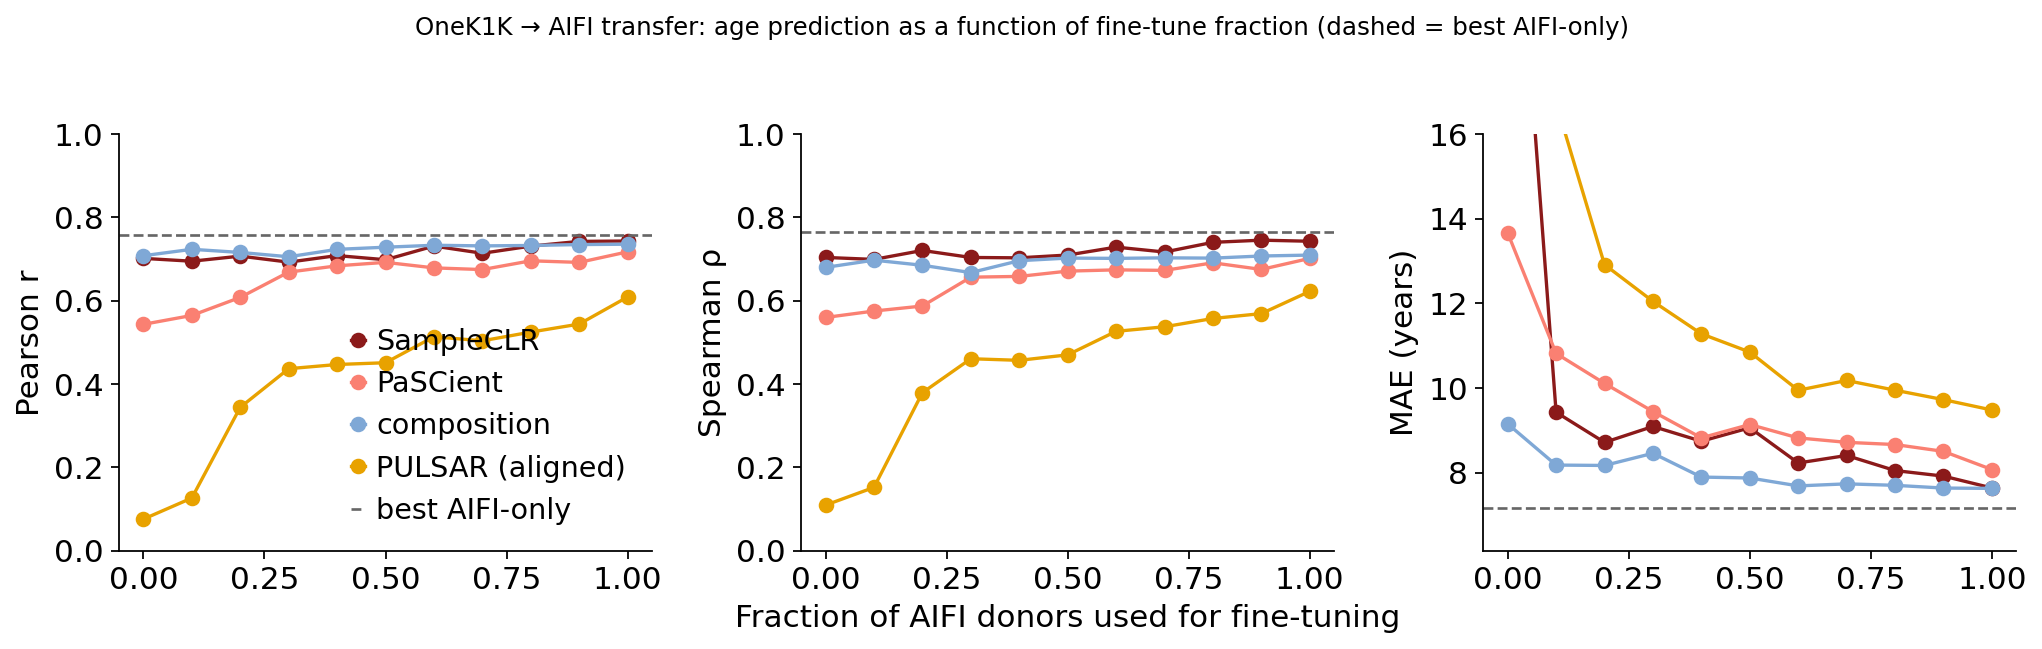

                      pearson_mean  spearman_mean  mae_mean  n_folds
method      fraction                                                
composition 0.0              0.707          0.679     9.153        5
            0.1              0.723          0.697     8.179        5
            0.2              0.715          0.685     8.170        5
            0.3              0.705          0.667     8.458        5
            0.4              0.723          0.695     7.896        5
            0.5              0.728          0.702     7.874        5
            0.6              0.733          0.701     7.688        5
            0.7              0.731          0.702     7.736        5
            0.8              0.732          0.702     7.701        5
            0.9              0.734          0.707     7.637        5
            1.0              0.735          0.709     7.629        5
pascient    0.0              0.543          0.559    13.662        5
            0.1              0.564

In [50]:
# Plot Pearson r / Spearman / MAE vs AIFI fine-tune fraction (mean across folds;
# MixMIL dropped from the sweep for poor performance). Dashed grey line = best
# AIFI-only score (the within-AIFI ceiling from the comparison above).
METHOD_ORDER = ["sampleclr", "pascient", "composition", "pulsar"]
METHOD_LABEL = {"sampleclr": "SampleCLR", "pascient": "PaSCient", "composition": "composition", "pulsar": "PULSAR (aligned)"}
sweep_colors = {"sampleclr": METHOD_COLORS["SampleCLR FT"], "pascient": METHOD_COLORS["PaSCient"], "composition": METHOD_COLORS["unsupervised"], "pulsar": METHOD_COLORS["PULSAR"]}
metrics = [("pearson", "Pearson r", (0, 1)), ("spearman", "Spearman ρ", (0, 1)),
           ("mae", "MAE (years)", None)]
# MAE floor = (smallest value actually drawn) - 1, so the readable range is not
# squashed against 0; the huge zero-shot MAE is still clipped at the top (16).
_mae_means = (sweep_df[sweep_df["method"].isin(METHOD_ORDER)]
              .groupby(["method", "fraction"])["mae"].mean())
mae_floor = min(_mae_means.min(), aging_scores["mae"].min()) - 1
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, label, ylim) in zip(axes, metrics):
    for method in METHOD_ORDER:
        sub = sweep_df[sweep_df["method"] == method].dropna(subset=[col])
        if sub.empty:
            continue
        agg = sub.groupby("fraction")[col].mean().reset_index()
        ax.plot(agg["fraction"].values, agg[col].values, marker="o",
                color=sweep_colors[method], label=METHOD_LABEL[method])
    best = aging_scores[col].min() if col == "mae" else aging_scores[col].max()
    ax.axhline(best, ls="--", color="0.4", lw=1.2,
               label="best AIFI-only" if col == "pearson" else None)
    ax.set_ylabel(label)
    if col == "mae":
        ax.set_ylim(mae_floor, 16)
    else:
        ax.set_ylim(*ylim)
    despine(ax)
axes[1].set_xlabel("Fraction of AIFI donors used for fine-tuning")
axes[0].legend(frameon=False, loc="best")
fig.suptitle("OneK1K → AIFI transfer: age prediction as a function of fine-tune fraction "
             "(dashed = best AIFI-only)", fontsize=11, y=1.02)
fig.tight_layout(); save_and_show("onek1k_to_aifi_sweep")
summary = (sweep_df.groupby(["method", "fraction"])
           .agg(pearson_mean=("pearson", "mean"), spearman_mean=("spearman", "mean"),
                mae_mean=("mae", "mean"), n_folds=("pearson", "count")).round(3))
print(summary.to_string())


## Persist trained models

The AIFI-pretrained state dicts for each method are the slow part of the
pipeline (PaSCient: ~10 min on GPU, MixMIL: ~5 min, SampleCLR: ~1 min).
We snapshot all three into a single ``torch.save`` archive so that
downstream analyses (e.g. running the FT-fraction sweep again with
different hyperparameters, or transferring to a third cohort) can
restore the weights without re-pretraining.

We also dump the FT-fraction sweep CSVs so the sweep can be re-plotted
without re-running.


## Take-aways

**Biology**

1. **The reproducible signal is compositional.** CLR-composition reaches
   `R²≈0.30` for held-out age on both AIFI and OneK1K. The same
   cell-type families move in the same direction in both cohorts: naive
   CD4 / CD8 T cells ↓, GZMB+ effectors and CD16+ monocytes ↑, naive B
   cells ↓.
2. **Within-cell-type transcription adds real predictive power.**
   PaSCient and SampleCLR-FT both beat composition on both cohorts. The
   attention deep-dive reveals what they're picking up: cytotoxic
   program in NK / effector-CD8, classical-monocyte activation, plasma
   cell signatures, etc.
3. **Fine-tuning concentrates the attention on age-discriminative cells.**
   SSL attention is roughly proportional to cell-type prevalence; FT
   attention shifts toward the cell types whose abundance and
   transcriptional state track age. The SSL-vs-FT scatter above makes
   this explicit.

**Method notes**

- **Scoring goes through patpy.** Unsupervised methods are scored with the
  built-in linear probe (`fit_linear_probe`, embedding methods) or KNN on the
  distance matrix (`predict_knn`, GloScope); supervised methods predict with
  their own head via `predict()`. All metrics come from
  `patpy.tl.evaluate_regression`.
- **Composition (CLR)** is the cheap interpretable baseline and the one
  that most cleanly replicates across cohorts. Use it first.
- **Pseudobulk** and **GloScope** add modest extra signal but inherit
  batch structure from `X_pca`.
- **PaSCient** consumes log-normalised gene expression (`adata.X`) with
  `normalize=False`; for cross-cohort transfer it runs on the shared gene panel.
  Predictions come straight from its native regression head.
- **MixMIL** only supports binomial / categorical likelihoods upstream, so we
  train its native head on the binary `age_group` and attach a regression linear
  probe (patpy's `fit_linear_probe(..., store=True)`) for continuous age.
- **Held-out scoring is honest for unsupervised, biased for supervised**
  (the supervised models saw test donors' ages during training). The
  cross-cohort agreement and the attention-driven biology are the more
  defensible comparisons.

For follow-up, the same template generalises to any donor-level
continuous target: BMI, severity scores, response to therapy,
time-to-event.
